In [23]:
import analysis_utils as utils
import pandas as pd
import numpy as np
import importlib
from sklearn.model_selection import GroupShuffleSplit

importlib.reload(utils)
print("Loading Data & Generating Artifacts...")
df, metrics, exp_info = utils.load_data_universal("db/results.sqlite")

df = df[df['Length'] <= 500].copy()

df = df[df['Length'] <= 500].copy()

df["null"] = 0 

# 2. Initialize the Group Splitter
# n_splits=1 gives you a single train/test split (like train_test_split)
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state= 42)

# 3. Generate the indices
# We pass the 'question_id_external' column as the 'groups' parameter
train_idx, test_idx = next(gss.split(df, groups=df['question_id_external']))

# 4. Create your new DataFrames
train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

Loading Data & Generating Artifacts...
Loading Run: HUV_Benchmark_Optimized (ID: 1)
Train shape: (2699, 28)
Test shape: (1175, 28)


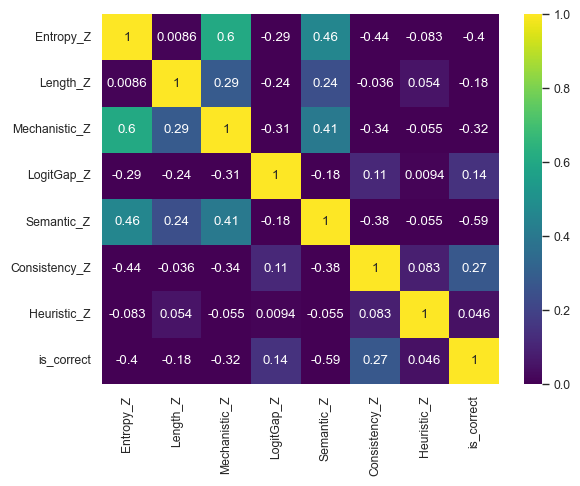

In [24]:
metrics = ["Entropy", "Length", "Mechanistic", "LogitGap", "Semantic", "Consistency", "Heuristic",]

metrics_z = [a + "_Z" for a in metrics] + ["is_correct"]

import seaborn as sns
import matplotlib.pyplot as plt

corr = df[metrics_z].corr()

sns.heatmap(
    corr,
    cmap="viridis",
    vmin=0,
    vmax=1,
    annot=True
)

plt.show()


Metric,Shift (Test),Train μ,Test μ,Test σ,Vis
Entropy,+2.56 SD,0.168,0.159,0.05,
Length,+0.21 SD,294.704,283.850,86.43,
Mechanistic,+1.38 SD,0.979,0.978,0.00,
LogitGap,-0.22 SD,0.022,0.022,0.03,
Metric,Shift (Test),Train μ,Test μ,Test σ,Vis
Entropy,+0.57 SD,0.077,0.079,0.02,
Length,-0.52 SD,227.112,224.849,45.65,
Mechanistic,+0.47 SD,0.970,0.970,0.00,
LogitGap,+0.13 SD,0.051,0.052,0.05,
Metric,Shift (Test),Train μ,Test μ,Test σ,Vis


Generating t-SNE on Train & Test Analysis...


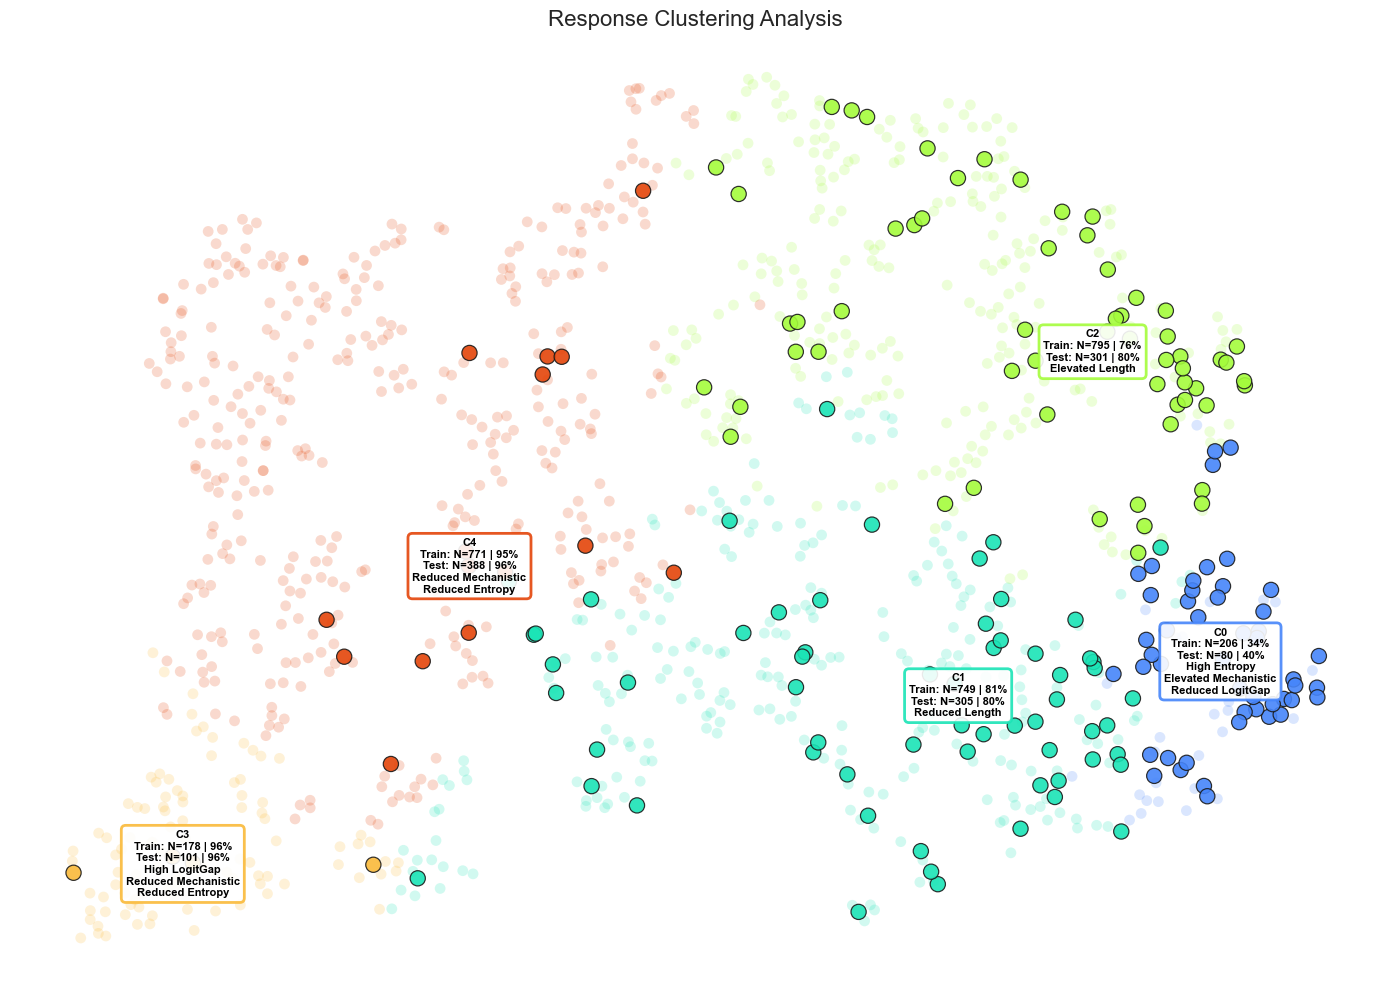

Generating Difficulty Stratification Plots...
Generating Stratified Plots for k=[0, 1, 2, 3, 4]...


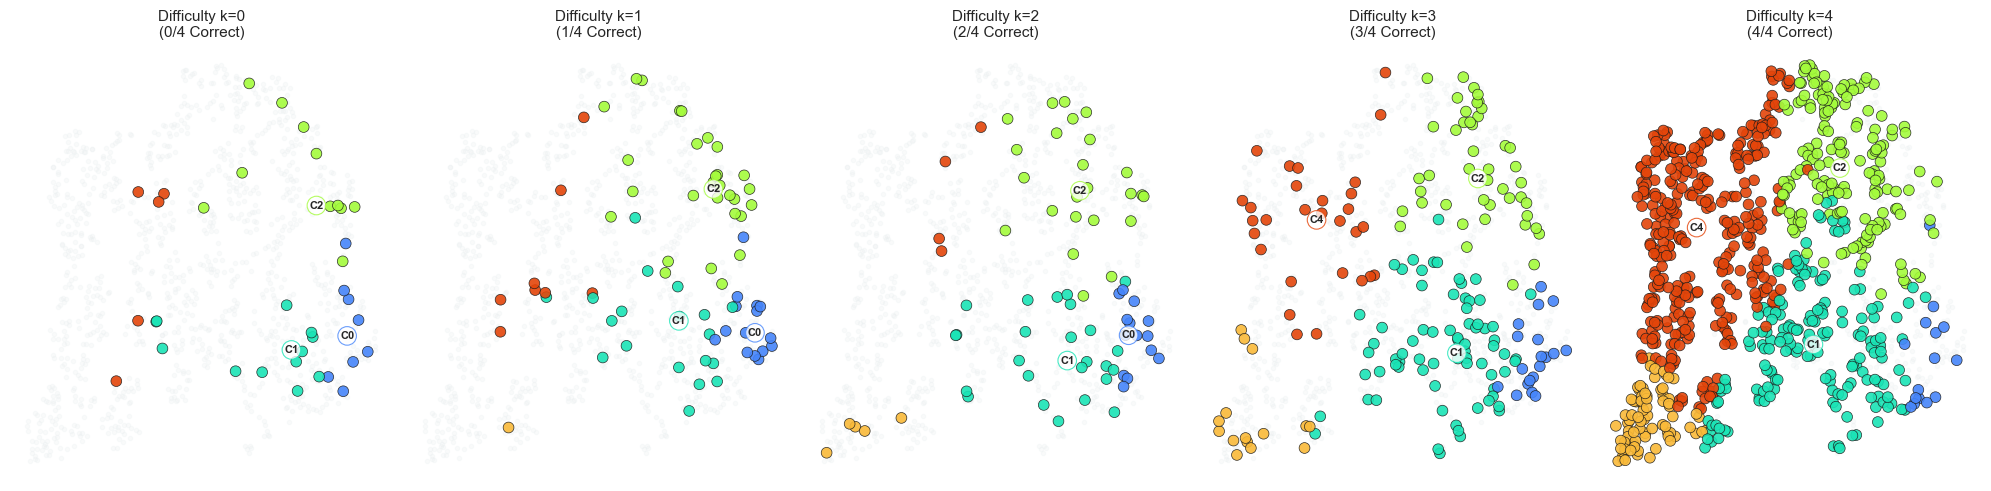

Generating Discrimination Bar Chart...


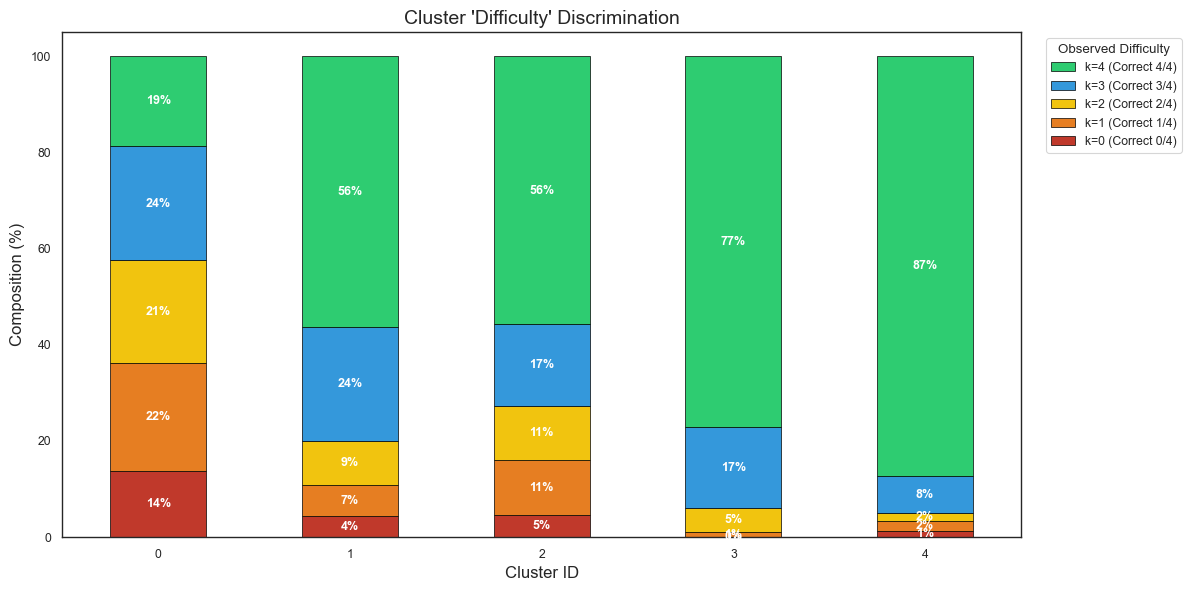


--- Pairwise Cluster Comparison (Same Question Overlap) ---


,Pair,Train_N,Train_Diff,Test_N,Test_Diff
0,C0 (34.5%) vs C1 (80.6%),74,-27.0%,34,-21.6%
1,C0 (34.5%) vs C2 (76.5%),62,-25.0%,25,-27.3%
2,C0 (34.5%) vs C3 (96.1%),7,-71.4%,3,-33.3%
3,C0 (34.5%) vs C4 (95.2%),21,-26.2%,7,-28.6%
4,C1 (80.6%) vs C2 (76.5%),164,-1.4%,61,-5.7%
5,C1 (80.6%) vs C3 (96.1%),62,-4.3%,25,-18.0%
6,C1 (80.6%) vs C4 (95.2%),172,-2.9%,55,-11.8%
7,C2 (76.5%) vs C3 (96.1%),31,-9.7%,15,-13.3%
8,C2 (76.5%) vs C4 (95.2%),101,-4.1%,31,-5.4%
9,C3 (96.1%) vs C4 (95.2%),88,-0.4%,56,-1.8%


In [25]:
cluster_predictor = utils.run_failure_modes_dashboard(train_df, exp_info, features=["Entropy", "Length", "Mechanistic", "LogitGap"], test_df = test_df, min_clusters = 5)

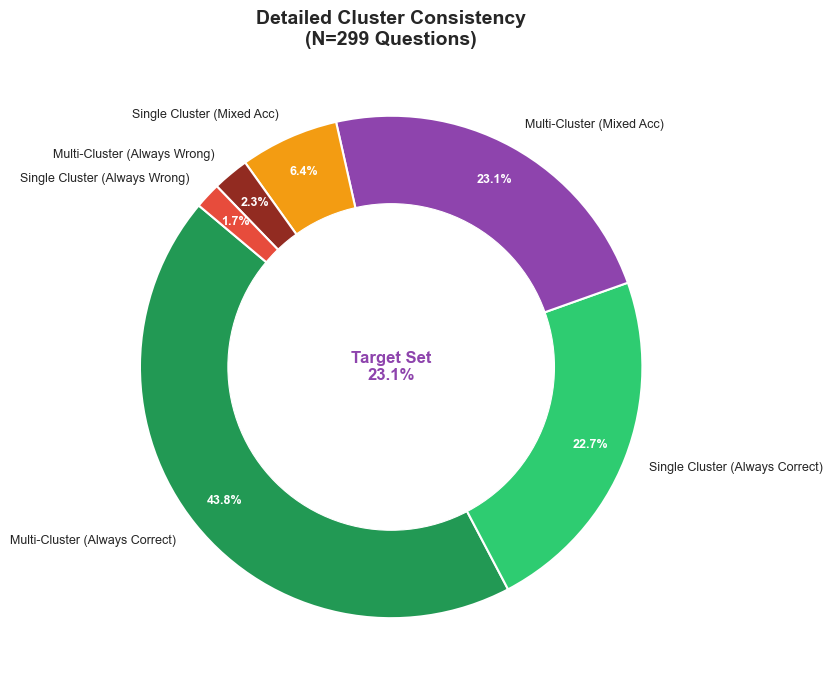

In [60]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_detailed_consistency_pie(df, cluster_classifier=None):
    """
    Plots a comprehensive donut chart separating Multi-Cluster vs Single-Cluster
    for ALL categories (Correct, Wrong, and Mixed).
    """
    # 1. Setup
    work_df = df.copy()
    if cluster_classifier:
        _, labels = cluster_classifier(work_df)
        work_df['Cluster'] = labels
    elif 'Cluster' not in work_df.columns:
        print("⚠️ Error: DataFrame must have a 'Cluster' column.")
        return

    group_col = 'question_id_external' if 'question_id_external' in work_df.columns else 'question_text'

    # 2. Strict Classification Logic
    def classify_strict(x):
        # A. Single Sample
        if len(x) < 2: return 'Single Sample'
        
        n_clusters = x['Cluster'].nunique()
        is_consistent = (x['Correct'].nunique() == 1)
        mean_acc = x['Correct'].mean()
        
        # B. ALWAYS CORRECT
        if mean_acc == 1.0:
            if n_clusters > 1: return 'Multi-Cluster (Always Correct)' # Robust
            else:              return 'Single Cluster (Always Correct)'
            
        # C. ALWAYS WRONG
        elif mean_acc == 0.0:
            if n_clusters > 1: return 'Multi-Cluster (Always Wrong)'
            else:              return 'Single Cluster (Always Wrong)'
            
        # D. MIXED ACCURACY
        else:
            if n_clusters > 1: return 'Multi-Cluster (Mixed Acc)' # TARGET
            else:              return 'Single Cluster (Mixed Acc)'

    # Apply & Count
    group_class = work_df.groupby(group_col).apply(classify_strict)
    counts = group_class.value_counts()
    total = len(group_class)
    
    # 3. Colors & Order (Grouped logically)
    # We use shades to group the concepts visually
    color_map = {
        # Green: Corrects
        'Multi-Cluster (Always Correct)':  '#229954', # Darker Green (Robust)
        'Single Cluster (Always Correct)': '#2ecc71', # Standard Green
        
        # Purple: The Target (Mixed + Multi)
        'Multi-Cluster (Mixed Acc)':       '#8e44ad', # Strong Purple
        
        # Orange/Yellow: Mixed + Single (The "Stuck" Noise)
        'Single Cluster (Mixed Acc)':      '#f39c12',
        
        # Red: Wrongs
        'Multi-Cluster (Always Wrong)':    '#922b21', # Darker Red (Stubborn)
        'Single Cluster (Always Wrong)':   '#e74c3c', # Standard Red
        
        # Grey: Single
        'Single Sample':                   '#bdc3c7'
    }
    
    # Sort by keys to keep legend consistent
    # Priority: Correct -> Target -> Mixed -> Wrong
    order = [
        'Multi-Cluster (Always Correct)', 'Single Cluster (Always Correct)',
        'Multi-Cluster (Mixed Acc)', 
        'Single Cluster (Mixed Acc)',
        'Multi-Cluster (Always Wrong)', 'Single Cluster (Always Wrong)',
        'Single Sample'
    ]
    
    # Filter Data
    labels = [l for l in order if l in counts.index]
    sizes = [counts[l] for l in labels]
    colors = [color_map[l] for l in labels]

    # 4. Plot
    fig, ax = plt.subplots(figsize=(11, 7))
    
    wedges, texts, autotexts = ax.pie(
        sizes, 
        labels=labels,
        autopct='%1.1f%%', 
        startangle=140,
        colors=colors,
        pctdistance=0.85,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
        textprops={'fontsize': 9}
    )
    
    # Styling
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_weight('bold')
        
    # Fix grey text for Single Sample if it exists
    for i, l in enumerate(labels):
        if l == 'Single Sample': autotexts[i].set_color('#555')

    # Center Circle
    fig.gca().add_artist(plt.Circle((0,0), 0.65, fc='white'))
    
    # Center Label
    target_count = counts.get('Multi-Cluster (Mixed Acc)', 0)
    ax.text(0, 0, f"Target Set\n{(target_count/total)*100:.1f}%", 
            ha='center', va='center', fontsize=12, fontweight='bold', color='#8e44ad')

    ax.set_title(f"Detailed Cluster Consistency\n(N={total} Questions)", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Usage
plot_detailed_consistency_pie(test_df, cluster_classifier=cluster_predictor)

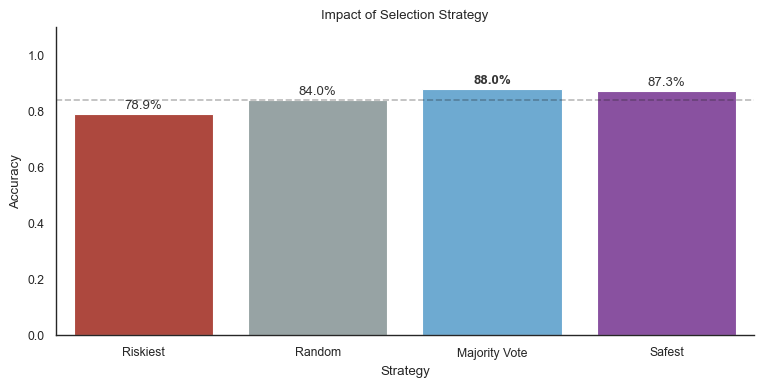

In [83]:
from IPython.display import HTML, display
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def analyze_intra_question_selection(test_df, cluster_predictor):
    """
    Uses a pre-trained clustering artifact to select the 'safest' answer 
    among multiple generations for the same question.
    
    Includes Majority Vote (Expected Value) as a competitive baseline.
    """
    # 1. Inference: Get Cluster Labels & "Safety" Probabilities
    probs, labels = cluster_predictor(test_df)
    
    # 2. Prepare Analysis DataFrame
    analysis_df = test_df.copy()
    analysis_df['Safety_Score'] = probs
    
    # Group by Question
    group_col = 'question_id_external' if 'question_id_external' in analysis_df.columns else 'question_text'
    ans_col = 'predicted_answer' if 'predicted_answer' in analysis_df.columns else 'full_trace_text'

    # Filter for questions where choice actually exists (Variance in Safety Scores)
    grouped = analysis_df.groupby(group_col).filter(lambda x: len(x) > 1 and x['Safety_Score'].nunique() > 1)
    
    if grouped.empty:
        print("⚠️ No valid multi-answer questions found for intra-question analysis.")
        return

    # 3. Compute Strategies
    # A. Cluster Strategies (Vectorized where possible)
    best_idx = grouped.groupby(group_col)['Safety_Score'].idxmax()
    worst_idx = grouped.groupby(group_col)['Safety_Score'].idxmin()
    
    acc_best = grouped.loc[best_idx, 'Correct'].mean()
    acc_worst = grouped.loc[worst_idx, 'Correct'].mean()
    
    # B. Random Baseline (Analytical Mean)
    acc_base = grouped['Correct'].mean()

    # C. Voting Strategy (Analytical Expected Value)
    def get_voting_ev(sub):
        counts = sub[ans_col].value_counts()
        candidates = counts[counts == counts.max()].index
        # Expected Value = Average correctness of tied winners
        return sub[sub[ans_col].isin(candidates)].groupby(ans_col)['Correct'].mean().mean()

    acc_vote = grouped.groupby(group_col).apply(get_voting_ev).mean()

    # 4. Visualization
    gain = acc_best - acc_base
    n_q = grouped[group_col].nunique()
    
    def color_score(val):
        if val > acc_base + 0.005: return "#27ae60" # Green
        if val < acc_base - 0.005: return "#c0392b" # Red
        return "#7f8c8d" # Grey
    
    # HTML KPI Card
    display(HTML(f"""
    <div style='border:1px solid #ddd; padding:20px; border-radius:10px; background:white; font-family:sans-serif; max-width: 850px'>
        <div style='border-bottom:1px solid #eee; padding-bottom:10px; margin-bottom:15px'>
            <h3 style='margin:0; color:#2c3e50'>Selection Strategy Showdown</h3>
            <div style='color:#7f8c8d; font-size:0.9em; margin-top:5px'>
                Comparing Cluster Safety against Random and Voting baselines (N={n_q} Questions).
            </div>
        </div>
        <div style='display:grid; grid-template-columns: 1fr 1fr 1fr 1fr; gap:10px; text-align:center; align-items:end'>
            <div style='opacity:0.7'>
                <div style='font-size:1.8em; color:#c0392b; font-weight:bold'>{acc_worst:.1%}</div>
                <div style='font-size:0.8em; font-weight:bold; color:#c0392b'>Riskiest</div>
            </div>
            <div>
                <div style='font-size:1.8em; color:#95a5a6; font-weight:bold'>{acc_base:.1%}</div>
                <div style='font-size:0.8em; font-weight:bold; color:#95a5a6'>Random</div>
            </div>
            <div>
                <div style='font-size:1.8em; color:{color_score(acc_vote)}; font-weight:bold'>{acc_vote:.1%}</div>
                <div style='font-size:0.8em; font-weight:bold; color:#2980b9'>Majority Vote</div>
            </div>
            <div>
                <div style='font-size:2.2em; color:{color_score(acc_best)}; font-weight:bold'>{acc_best:.1%}</div>
                <div style='font-size:0.8em; font-weight:bold; color:#8e44ad'>Safest Cluster</div>
            </div>
        </div>
        <div style='margin-top:20px; background:#f9f9f9; padding:10px; border-radius:6px; text-align:center'>
            <span style='color:#2c3e50; font-weight:600'>Cluster Gain vs Random:</span> 
            <span style='color:{color_score(acc_best)}; font-weight:bold; font-size:1.1em'> {gain:+.1%} </span>
            &nbsp;|&nbsp; 
            <span style='color:#2c3e50; font-weight:600'>vs Voting:</span>
            <span style='color:{color_score(acc_best - acc_vote)}; font-weight:bold; font-size:1.1em'> {acc_best - acc_vote:+.1%} </span>
        </div>
    </div>
    """))

    # Plot
    plot_data = pd.DataFrame({
        'Strategy': ['Riskiest', 'Random', 'Majority Vote', 'Safest'],
        'Accuracy': [acc_worst, acc_base, acc_vote, acc_best]
    })
    
    plt.figure(figsize=(9, 4))
    ax = sns.barplot(data=plot_data, x='Strategy', y='Accuracy', palette=['#c0392b', '#95a5a6', '#5dade2', '#8e44ad'])
    plt.ylim(0, 1.1)
    plt.axhline(acc_base, color='k', linestyle='--', alpha=0.3, label='Baseline')
    
    for i, v in enumerate(plot_data['Accuracy']):
        weight = 'bold' if v == plot_data['Accuracy'].max() else 'normal'
        ax.text(i, v + 0.02, f"{v:.1%}", ha='center', fontweight=weight, color='#333')
        
    sns.despine()
    plt.title("Impact of Selection Strategy")
    plt.show()

# Usage:
analyze_intra_question_selection(test_df, cluster_predictor)

Category,Questions,%
Excluded: All Correct,131,43.8%
Excluded: Single Cluster,92,30.8%
Kept: Inconsistent Set,69,23.1%
Excluded: All Wrong,7,2.3%


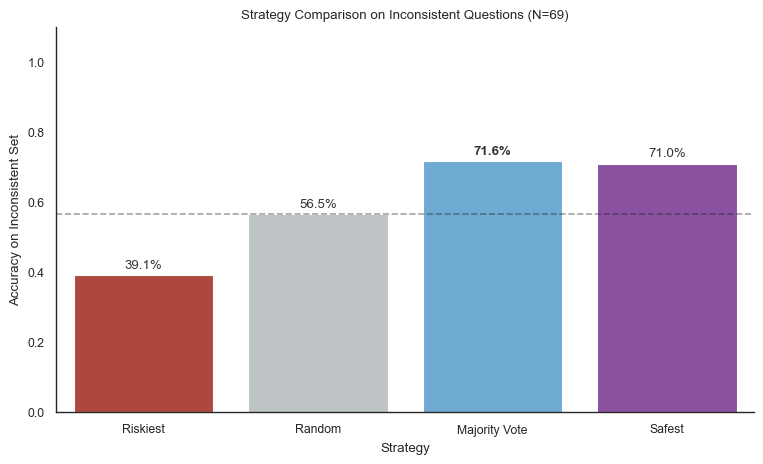

In [80]:
from IPython.display import HTML, display
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def analyze_intra_question_selection(test_df, cluster_predictor):
    """
    Analyzes selection strategies using Expected Values (mass distribution) 
    rather than single-shot random sampling.
    
    Strategies (4-Way):
    1. Riskiest Cluster
    2. Random Baseline (Expected Value)
    3. Majority Vote (Random Tiebreak - Expected Value)
    4. Safest Cluster
    """
    # --- 1. PREP & INFERENCE ---
    probs, labels = cluster_predictor(test_df)
    
    analysis_df = test_df.copy()
    analysis_df['Safety_Score'] = probs
    analysis_df['Cluster_Label'] = labels
    
    group_col = 'question_id_external' if 'question_id_external' in analysis_df.columns else 'question_text'
    ans_col = 'predicted_answer' if 'predicted_answer' in analysis_df.columns else 'full_trace_text'
    
    # --- 2. CLASSIFY & LOG EXCLUSIONS ---
    def classify_question_group(x):
        if len(x) < 2: return "Excluded: Single Sample"
        if x['Cluster_Label'].nunique() <= 1: return "Excluded: Single Cluster"
        if x['Correct'].nunique() <= 1:
            if x['Correct'].mean() == 1.0: return "Excluded: All Correct"
            if x['Correct'].mean() == 0.0: return "Excluded: All Wrong"
        return "Kept: Inconsistent Set"

    group_status = analysis_df.groupby(group_col).apply(classify_question_group)
    analysis_df = analysis_df.merge(group_status.rename('Status'), on=group_col)
    
    # Display Log
    status_counts = group_status.value_counts().reset_index()
    status_counts.columns = ['Category', 'Count']
    status_counts['Percent'] = (status_counts['Count'] / status_counts['Count'].sum())
    
    log_html = f"<div style='margin-bottom:20px; font-family:sans-serif; border:1px solid #eee; border-radius:8px; overflow:hidden;'><div style='background:#f8f9fa; padding:10px 15px; border-bottom:1px solid #eee; font-weight:bold; color:#555;'>Data Funnel: Exclusion Log</div><table style='width:100%; border-collapse:collapse; font-size:0.9em;'><tr style='background:#fff; border-bottom:2px solid #f0f0f0;'><th style='text-align:left; padding:8px 15px; color:#999;'>Category</th><th style='text-align:right; padding:8px 15px; color:#999;'>Questions</th><th style='text-align:right; padding:8px 15px; color:#999;'>%</th></tr>"
    for _, row in status_counts.iterrows():
        cat = row['Category']
        bg = "#eafaf1" if "Kept" in cat else "#fff"
        weight = "bold" if "Kept" in cat else "normal"
        color = "#27ae60" if "Kept" in cat else "#7f8c8d"
        log_html += f"<tr style='background:{bg}; border-bottom:1px solid #f9f9f9;'><td style='padding:8px 15px; font-weight:{weight}; color:{color}'>{cat}</td><td style='text-align:right; padding:8px 15px; font-weight:{weight}; color:{color}'>{row['Count']}</td><td style='text-align:right; padding:8px 15px; color:#999'>{row['Percent']:.1%}</td></tr>"
    log_html += "</table></div>"
    display(HTML(log_html))

    # --- 3. COMPUTE STRATEGIES ---
    grouped_df = analysis_df[analysis_df['Status'] == "Kept: Inconsistent Set"]
    if grouped_df.empty:
        print("⚠️ No inconsistent questions found.")
        return

    # A. Cluster Strategies (Min/Max Safety Score)
    best_idx = grouped_df.groupby(group_col)['Safety_Score'].idxmax()
    worst_idx = grouped_df.groupby(group_col)['Safety_Score'].idxmin()
    acc_best = grouped_df.loc[best_idx, 'Correct'].mean()
    acc_worst = grouped_df.loc[worst_idx, 'Correct'].mean()
    
    # B. Random Baseline (Analytical)
    # The expected value of a random draw is just the mean accuracy of the group
    acc_base = grouped_df.groupby(group_col)['Correct'].mean().mean()

    # C. Voting Strategy (Analytical Expected Value)
    def get_voting_ev(sub):
        # 1. Count votes per unique answer string
        counts = sub[ans_col].value_counts()
        max_votes = counts.max()
        
        # 2. Identify the winners (could be 1, could be ties)
        candidates = counts[counts == max_votes].index
        
        # 3. Calculate Correctness of each Candidate answer
        # We group by answer string to get the correctness of that specific answer text
        # (Assuming correctness is deterministic per answer string)
        cand_correctness = sub[sub[ans_col].isin(candidates)].groupby(ans_col)['Correct'].mean()
        
        # 4. Expected Value = Average correctness of the tied candidates
        # (Equivalent to equally distributing probability mass among ties)
        return cand_correctness.mean()

    acc_vote = grouped_df.groupby(group_col).apply(get_voting_ev).mean()

    # --- 4. VISUALIZATION ---
    n_q = grouped_df[group_col].nunique()
    
    def color_score(val):
        if val > acc_base + 0.005: return "#27ae60"
        if val < acc_base - 0.005: return "#c0392b"
        return "#7f8c8d"

    display(HTML(f"""
    <div style='border:1px solid #ddd; padding:20px; border-radius:10px; background:white; font-family:sans-serif; max-width: 800px; box-shadow: 0 4px 6px rgba(0,0,0,0.05)'>
        <div style='border-bottom:1px solid #eee; padding-bottom:10px; margin-bottom:15px'>
            <h3 style='margin:0; color:#2c3e50'>Selection Strategy Showdown (4-Way)</h3>
            <div style='color:#7f8c8d; font-size:0.9em; margin-top:5px'>
                Comparing Cluster Safety against Random and Voting baselines (Inconsistent Set, N={n_q}).
            </div>
        </div>
        
        <div style='display:grid; grid-template-columns: 1fr 1fr 1fr 1fr; gap:10px; text-align:center; align-items:end'>
            <div style='opacity:0.7'>
                <div style='font-size:2em; color:#c0392b; font-weight:bold'>{acc_worst:.1%}</div>
                <div style='font-size:0.8em; font-weight:bold; color:#c0392b; margin-top:5px'>Riskiest</div>
            </div>
            <div>
                <div style='font-size:2em; color:#95a5a6; font-weight:bold'>{acc_base:.1%}</div>
                <div style='font-size:0.8em; font-weight:bold; color:#95a5a6; margin-top:5px'>Random</div>
            </div>
            <div>
                <div style='font-size:2em; color:{color_score(acc_vote)}; font-weight:bold'>{acc_vote:.1%}</div>
                <div style='font-size:0.8em; font-weight:bold; color:#2980b9; margin-top:5px'>Majority Vote</div>
            </div>
            <div>
                <div style='font-size:2.4em; color:{color_score(acc_best)}; font-weight:bold'>{acc_best:.1%}</div>
                <div style='font-size:0.8em; font-weight:bold; color:#8e44ad; margin-top:5px'>Safest Cluster</div>
            </div>
        </div>
        
        <div style='margin-top:20px; background:#f9f9f9; padding:10px; border-radius:6px; text-align:center'>
            <span style='color:#2c3e50; font-weight:600'>Cluster Gain vs Random:</span> 
            <span style='color:{color_score(acc_best)}; font-weight:bold; font-size:1.1em'> {acc_best - acc_base:+.1%} </span>
            &nbsp;|&nbsp; 
            <span style='color:#2c3e50; font-weight:600'>vs Voting:</span>
            <span style='color:{color_score(acc_best - acc_vote)}; font-weight:bold; font-size:1.1em'> {acc_best - acc_vote:+.1%} </span>
        </div>
    </div>
    """))

    # Plot
    plot_data = pd.DataFrame({
        'Strategy': ['Riskiest', 'Random', 'Majority Vote', 'Safest'],
        'Accuracy': [acc_worst, acc_base, acc_vote, acc_best]
    })
    
    plt.figure(figsize=(9, 5))
    colors = ['#c0392b', '#bdc3c7', '#5dade2', '#8e44ad']
    
     

    ax = sns.barplot(data=plot_data, x='Strategy', y='Accuracy', palette=colors)
    plt.ylim(0, 1.1)
    plt.axhline(acc_base, color='k', linestyle='--', alpha=0.4, label='Baseline')
    
    for i, v in enumerate(plot_data['Accuracy']):
        weight = 'bold' if v == plot_data['Accuracy'].max() else 'normal'
        ax.text(i, v + 0.02, f"{v:.1%}", ha='center', fontweight=weight, color='#333')
        
    sns.despine()
    plt.ylabel("Accuracy on Inconsistent Set")
    plt.title(f"Strategy Comparison on Inconsistent Questions (N={n_q})")
    plt.show()

# Usage:
analyze_intra_question_selection(test_df, cluster_predictor)

In [44]:
import pandas as pd
import numpy as np
from itertools import combinations
from IPython.display import display, HTML
import re

def plot_pairwise_improvement_table(train_df, cluster_classifier, test_df=None):
    """
    Generates a polished HTML table comparing cluster pairs on SHARED questions.
    
    Args:
        train_df: Training DataFrame (must contain 'question_id_external' and 'Correct').
        cluster_classifier: Your PredictorArtifact or callable returning (probs, labels).
        test_df: Optional Test DataFrame.
    """
    
    # --- 1. SETUP & PREDICTION ---
    # We work on copies to avoid modifying your original dataframes
    train_work = train_df.copy()
    
    # Run the classifier on Train
    _, train_labels = cluster_classifier(train_work)
    train_work['Cluster'] = train_labels

    if test_df is not None:
        test_work = test_df.copy()
        _, test_labels = cluster_classifier(test_work)
        test_work['Cluster'] = test_labels
    else:
        test_work = None

    # --- 2. CSS STYLING (Clean & Presentation Ready) ---
    css = """
    <style>
        .pw-container { font-family: 'Segoe UI', sans-serif; margin-top: 20px; border: 1px solid #e0e0e0; border-radius: 8px; overflow: hidden; box-shadow: 0 4px 10px rgba(0,0,0,0.03); max-width: 1000px; }
        .pw-header { padding: 20px; background: #fafafa; border-bottom: 1px solid #eee; }
        .pw-title { margin: 0; color: #2c3e50; font-size: 1.2em; font-weight: 600; }
        .pw-subtitle { font-size: 0.9em; color: #7f8c8d; margin-top: 5px; line-height: 1.4; }
        
        .pw-table { width: 100%; border-collapse: collapse; background: white; }
        /* Adjusted padding and alignment for better column visual */
        .pw-table th { background: white; color: #95a5a6; font-weight: 600; font-size: 0.75em; text-transform: uppercase; letter-spacing: 0.5px; padding: 12px 15px; text-align: center; border-bottom: 2px solid #f0f0f0; }
        .pw-table th:first-child { text-align: left; padding-left: 20px; } /* Align first header left */
        
        .pw-table td { padding: 10px 15px; border-bottom: 1px solid #f9f9f9; vertical-align: middle; font-size: 0.9em; color: #34495e; text-align: center; }
        .pw-table td:first-child { text-align: left; padding-left: 20px; } /* Align first col left */
        .pw-table tr:hover { background-color: #f8f9fa; transition: background 0.1s; }
        
        /* Strategy Flow Visualization */
        .strategy-flow { display: flex; align-items: center; gap: 8px; }
        .c-pill { padding: 4px 10px; border-radius: 12px; font-weight: 600; font-size: 0.85em; color: white; min-width: 30px; text-align: center; box-shadow: 0 1px 2px rgba(0,0,0,0.1); }
        .c-acc { color: #7f8c8d; font-size: 0.9em; }
        .arrow-icon { color: #bdc3c7; font-size: 1.1em; font-weight: bold; margin: 0 4px; }
        
        /* Expected Gain Column */
        .exp-gain { color: black; font-weight: bold; font-size: 0.95em; }

        /* Delta Indicators */
        .delta-box { padding: 4px 8px; border-radius: 6px; font-weight: 700; font-size: 0.9em; display: inline-block; min-width: 65px; text-align: center; }
        .d-pos { background: #eafaf1; color: #27ae60; border: 1px solid #d5f5e3; } /* Green */
        .d-neg { background: #fdedec; color: #c0392b; border: 1px solid #fadbd8; } /* Red */
        .d-neu { background: #f4f6f6; color: #95a5a6; border: 1px solid #eaeded; font-weight: normal;} /* Grey */
        
        /* Sample Size Tag */
        .n-tag { background: #fdfefe; border: 1px solid #e0e0e0; color: #7f8c8d; padding: 2px 6px; border-radius: 4px; font-size: 0.8em; font-family: monospace; }
        
        /* Consistent Palette Generator */
        .bg-0 { background-color: #3498db; } /* Blue */
        .bg-1 { background-color: #e74c3c; } /* Red */
        .bg-2 { background-color: #f1c40f; } /* Yellow */
        .bg-3 { background-color: #2ecc71; } /* Green */
        .bg-4 { background-color: #9b59b6; } /* Purple */
        .bg-5 { background-color: #e67e22; } /* Orange */
        .bg-def { background-color: #95a5a6; }
    </style>
    """

    # --- 3. HELPER LOGIC ---
    
    def get_cid(label):
        if isinstance(label, (int, float)): return int(label)
        match = re.search(r'\d+', str(label))
        return int(match.group()) if match else 0

    global_acc = train_work.groupby('Cluster')['Correct'].mean()
    unique_clusters = sorted(train_work['Cluster'].unique())

    def get_stats(df_in, c_low, c_high):
        if df_in is None: return 0, np.nan
        q_stats = df_in.groupby(['Cluster', 'question_id_external'])['Correct'].mean()
        if c_low not in q_stats or c_high not in q_stats: return 0, np.nan
        
        shared = q_stats.loc[c_low].index.intersection(q_stats.loc[c_high].index)
        n = len(shared)
        if n == 0: return 0, np.nan
        
        diff = (q_stats.loc[c_high].loc[shared] - q_stats.loc[c_low].loc[shared]).mean()
        return n, diff

    # --- 4. BUILD TABLE ROWS ---
    rows_html = ""
    valid_pairs = 0
    
    for c1, c2 in combinations(unique_clusters, 2):
        acc1, acc2 = global_acc.get(c1, 0), global_acc.get(c2, 0)
        
        # Ensure Left=Worse, Right=Better
        if acc1 < acc2:
            left, right = c1, c2
            left_acc, right_acc = acc1, acc2
        else:
            left, right = c2, c1
            left_acc, right_acc = acc2, acc1
            
        # Get Stats
        n_train, diff_train = get_stats(train_work, left, right)
        if n_train == 0: continue 
        
        n_test, diff_test = get_stats(test_work, left, right)
        valid_pairs += 1
        
        # Calculate Simple Expected Gain (Global difference)
        exp_gain = right_acc - left_acc
        
        def fmt_d(val):
            if pd.isna(val): return '<span class="delta-box d-neu">-</span>'
            cls = "d-pos" if val > 0.005 else ("d-neg" if val < -0.005 else "d-neu")
            sign = "+" if val > 0 else ""
            return f'<span class="delta-box {cls}">{sign}{val:.1%}</span>'
        
        c_l_bg = f"bg-{get_cid(left) % 6}"
        c_r_bg = f"bg-{get_cid(right) % 6}"

        # Adjusted Column Widths: First column reduced to 30%, new column added
        rows_html += f"""
        <tr>
            <td style="width: 30%">
                <div class="strategy-flow">
                    <div class="c-pill {c_l_bg}">{left}</div>
                    <div class="c-acc">{left_acc:.1%}</div>
                    <div class="arrow-icon">➜</div>
                    <div class="c-pill {c_r_bg}">{right}</div>
                    <div class="c-acc">{right_acc:.1%}</div>
                </div>
            </td>
            <td style="width: 15%;" class="exp-gain">+{exp_gain:.1%}</td>
            <td style="width: 13%"><span class="n-tag">N={n_train}</span></td>
            <td style="width: 13%">{fmt_d(diff_train)}</td>
            <td style="width: 13%"><span class="n-tag">N={n_test if test_work is not None else 0}</span></td>
            <td style="width: 13%">{fmt_d(diff_test)}</td>
        </tr>
        """

    if valid_pairs == 0:
        rows_html = '<tr><td colspan="6" style="text-align:center; padding:20px; color:#95a5a6">No shared questions found between clusters.</td></tr>'

    # --- 5. RENDER FINAL HTML ---
    full_html = f"""
    {css}
    <div class="pw-container">
        <div class="pw-header">
            <h3 class="pw-title">Cluster Pairwise Comparison</h3>
            <div class="pw-subtitle">
                Isolating <b>Shared Questions</b> to measure the pure performance gain of switching clusters.<br>
                <span style="color:#27ae60; font-weight:bold">Positive (+%)</span> indicates the right-hand cluster is strictly better on identical inputs.
            </div>
        </div>
        <table class="pw-table">
            <thead>
                <tr>
                    <th>Strategy Path (Worse ➜ Better)</th>
                    <th>Theoretical 'Expected' Gain</th>
                    <th>Train Support</th>
                    <th>Train Gain</th>
                    <th>Test Support</th>
                    <th>Test Gain</th>
                </tr>
            </thead>
            <tbody>
                {rows_html}
            </tbody>
        </table>
    </div>
    """
    
    display(HTML(full_html))
    
# Example usage:
plot_pairwise_improvement_table(train_df, cluster_predictor, test_df=test_df)

Strategy Path (Worse ➜ Better),Theoretical 'Expected' Gain,Train Support,Train Gain,Test Support,Test Gain
Cluster 0 34.5% ➜ Cluster 1 80.6%,+46.2%,N=74,+27.0%,N=34,+21.6%
Cluster 0 34.5% ➜ Cluster 2 76.5%,+42.0%,N=62,+25.0%,N=25,+27.3%
Cluster 0 34.5% ➜ Cluster 3 96.1%,+61.6%,N=7,+71.4%,N=3,+33.3%
Cluster 0 34.5% ➜ Cluster 4 95.2%,+60.7%,N=21,+26.2%,N=7,+28.6%
Cluster 2 76.5% ➜ Cluster 1 80.6%,+4.2%,N=164,-1.4%,N=61,-5.7%
Cluster 1 80.6% ➜ Cluster 3 96.1%,+15.4%,N=62,+4.3%,N=25,+18.0%
Cluster 1 80.6% ➜ Cluster 4 95.2%,+14.6%,N=172,+2.9%,N=55,+11.8%
Cluster 2 76.5% ➜ Cluster 3 96.1%,+19.6%,N=31,+9.7%,N=15,+13.3%
Cluster 2 76.5% ➜ Cluster 4 95.2%,+18.7%,N=101,+4.1%,N=31,+5.4%
Cluster 4 95.2% ➜ Cluster 3 96.1%,+0.9%,N=88,-0.4%,N=56,-1.8%


Category,Questions,%
Excluded: All Correct,131,43.8%
Excluded: Single Cluster,92,30.8%
Kept: Inconsistent Set,69,23.1%
Excluded: All Wrong,7,2.3%


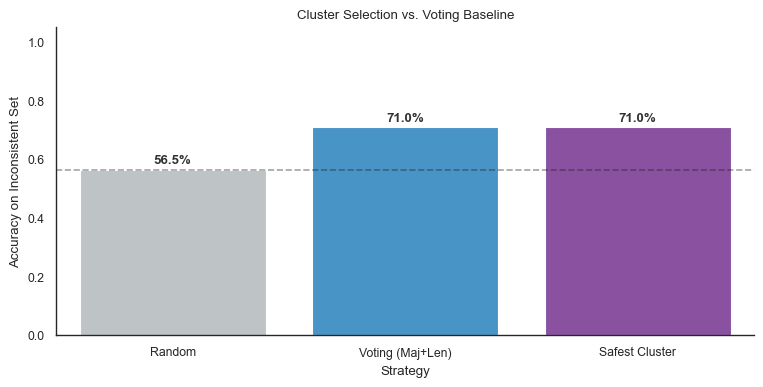

In [75]:
from IPython.display import HTML, display
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def analyze_intra_question_selection(test_df, cluster_predictor):
    """
    Uses a pre-trained clustering artifact to select the 'safest' answer 
    among multiple generations. 
    
    Includes a VOTING BASELINE (Majority Vote -> Break ties with 'Length' column).
    """
    # 1. Inference: Get Safety Scores & Labels
    probs, labels = cluster_predictor(test_df)
    
    # 2. Prepare Analysis DataFrame
    analysis_df = test_df.copy()
    analysis_df['Safety_Score'] = probs
    analysis_df['Cluster_Label'] = labels
    
    # Ensure Length column exists, otherwise fallback
    if 'Length' not in analysis_df.columns:
        print("⚠️ 'Length' column not found. Calculating on the fly...")
        ans_col = 'predicted_answer' if 'predicted_answer' in analysis_df.columns else 'full_trace_text'
        analysis_df['Length'] = analysis_df[ans_col].astype(str).apply(len)

    # Determine grouping column
    group_col = 'question_id_external' if 'question_id_external' in analysis_df.columns else 'question_text'
    
    # --- 3. CLASSIFY & LOG GROUPS ---
    
    def classify_question_group(x):
        # 1. Filter: Single Answer
        if len(x) < 2: 
            return "Excluded: Single Sample"
            
        # 2. Filter: Single Cluster (No Choice available for clustering)
        if x['Cluster_Label'].nunique() <= 1:
            return "Excluded: Single Cluster"
            
        # 3. Filter: Fixed Accuracy (Selection doesn't matter)
        if x['Correct'].nunique() <= 1:
            if x['Correct'].mean() == 1.0: return "Excluded: All Correct"
            if x['Correct'].mean() == 0.0: return "Excluded: All Wrong"
        
        # 4. Kept
        return "Kept: Inconsistent Set"

    # Apply classification
    group_status = analysis_df.groupby(group_col).apply(classify_question_group)
    analysis_df = analysis_df.merge(group_status.rename('Status'), on=group_col)
    
    # --- 4. DISPLAY EXCLUSION LOG ---
    status_counts = group_status.value_counts().reset_index()
    status_counts.columns = ['Category', 'Count']
    status_counts['Percent'] = (status_counts['Count'] / status_counts['Count'].sum())
    
    # Create a nice HTML table for the log
    log_html = f"""
    <div style="margin-bottom: 20px; font-family: sans-serif; border: 1px solid #eee; border-radius: 8px; overflow: hidden;">
        <div style="background: #f8f9fa; padding: 10px 15px; border-bottom: 1px solid #eee; font-weight: bold; color: #555;">
            Data Funnel: Exclusion Log
        </div>
        <table style="width: 100%; border-collapse: collapse; font-size: 0.9em;">
            <tr style="background: #fff; border-bottom: 2px solid #f0f0f0;">
                <th style="text-align: left; padding: 8px 15px; color: #999;">Category</th>
                <th style="text-align: right; padding: 8px 15px; color: #999;">Questions</th>
                <th style="text-align: right; padding: 8px 15px; color: #999;">%</th>
            </tr>
    """
    
    for _, row in status_counts.iterrows():
        cat = row['Category']
        count = row['Count']
        pct = row['Percent']
        bg = "#eafaf1" if "Kept" in cat else "#fff"
        weight = "bold" if "Kept" in cat else "normal"
        color = "#27ae60" if "Kept" in cat else "#7f8c8d"
        
        log_html += f"""
        <tr style="background: {bg}; border-bottom: 1px solid #f9f9f9;">
            <td style="padding: 8px 15px; font-weight: {weight}; color: {color};">{cat}</td>
            <td style="text-align: right; padding: 8px 15px; font-weight: {weight}; color: {color};">{count}</td>
            <td style="text-align: right; padding: 8px 15px; color: #999;">{pct:.1%}</td>
        </tr>
        """
    log_html += "</table></div>"
    display(HTML(log_html))

    # --- 5. COMPUTE STRATEGIES ON KEPT SET ---
    grouped_df = analysis_df[analysis_df['Status'] == "Kept: Inconsistent Set"]
    
    if grouped_df.empty:
        print("⚠️ No inconsistent questions found after filtering.")
        return

    # A. Cluster Strategies
    best_idx = grouped_df.groupby(group_col)['Safety_Score'].idxmax()
    worst_idx = grouped_df.groupby(group_col)['Safety_Score'].idxmin()
    
    acc_best = grouped_df.loc[best_idx, 'Correct'].mean()
    acc_worst = grouped_df.loc[worst_idx, 'Correct'].mean()
    acc_base = grouped_df['Correct'].mean() # Random selection

    # B. Voting Strategy (Majority Vote -> Length Tie-Breaker)
    # We calculate this manually per group
    ans_col = 'predicted_answer' if 'predicted_answer' in grouped_df.columns else 'full_trace_text'
    
    def get_voting_winner(sub):
        # Count occurrences of each answer string
        counts = sub[ans_col].value_counts()
        max_votes = counts.max()
        # Get candidates with max votes
        candidates = counts[counts == max_votes].index
        
        # Filter subset to just those candidates
        ties = sub[sub[ans_col].isin(candidates)]
        
        # Break ties by Length (shortest)
        # Sort by 'Length' column ascending, then pick top
        # winner = ties.sort_values('Length', ascending=False).iloc[0]

        winner = ties.sample(n=1).iloc[0]
        return winner['Correct']
        # return winner['Correct']

    # Apply Voting
    acc_vote = grouped_df.groupby(group_col).apply(get_voting_winner).mean()

    # --- 6. VISUALIZATION ---
    gain = acc_best - acc_base
    n_q = grouped_df[group_col].nunique()
    
    # Helper to color score relative to baseline
    def color_score(val):
        if val > acc_base + 0.01: return "#27ae60" # Green
        if val < acc_base - 0.01: return "#c0392b" # Red
        return "#7f8c8d" # Grey
    
    # HTML KPI Card
    display(HTML(f"""
    <div style='border:1px solid #ddd; padding:20px; border-radius:10px; background:white; font-family:sans-serif; max-width: 900px; box-shadow: 0 4px 6px rgba(0,0,0,0.05)'>
        <div style='border-bottom:1px solid #eee; padding-bottom:10px; margin-bottom:15px'>
            <h3 style='margin:0; color:#2c3e50'>Selection Strategy Showdown</h3>
            <div style='color:#7f8c8d; font-size:0.9em; margin-top:5px'>
                Comparing Cluster Safety against Random and Voting baselines on the <b>Inconsistent Set</b>.
            </div>
        </div>
        
        <div style='display:flex; justify-content:space-between; align-items:center; text-align:center; padding: 10px 0;'>
            
            <div style='flex:1; opacity:0.7'>
                <div style='font-size:0.85em; text-transform:uppercase; letter-spacing:1px'>Random</div>
                <div style='font-size:1.8em; color:#95a5a6; font-weight:bold'>{acc_base:.1%}</div>
            </div>

            <div style='width:1px; height:40px; background:#eee'></div>

            <div style='flex:1'>
                <div style='font-size:0.85em; text-transform:uppercase; letter-spacing:1px; color:#2980b9'>Voting</div>
                <div style='font-size:1.8em; color:{color_score(acc_vote)}; font-weight:bold'>{acc_vote:.1%}</div>
                <div style='font-size:0.75em; color:#999'>Majority + Shortest</div>
            </div>

            <div style='width:1px; height:40px; background:#eee'></div>

            <div style='flex:1'>
                <div style='font-size:0.85em; text-transform:uppercase; letter-spacing:1px; color:#8e44ad'>Safest Cluster</div>
                <div style='font-size:2.2em; color:{color_score(acc_best)}; font-weight:bold'>{acc_best:.1%}</div>
            </div>
            
        </div>
        
        <div style='margin-top:20px; background:#f9f9f9; padding:10px; border-radius:6px; text-align:center'>
            <span style='color:#2c3e50; font-weight:600'>Cluster Gain vs Random:</span> 
            <span style='color:{color_score(acc_best)}; font-weight:bold; font-size:1.1em'> {gain:+.1%} </span>
            &nbsp;|&nbsp; 
            <span style='color:#2c3e50; font-weight:600'>vs Voting:</span>
            <span style='color:{color_score(acc_best - acc_vote)}; font-weight:bold; font-size:1.1em'> {acc_best - acc_vote:+.1%} </span>
        </div>
    </div>
    """))

    # Plot
    plot_data = pd.DataFrame({
        'Strategy': ['Random', 'Voting (Maj+Len)', 'Safest Cluster'],
        'Accuracy': [acc_base, acc_vote, acc_best]
    })
    
    plt.figure(figsize=(9, 4))
    # Using a palette that highlights the progression
    ax = sns.barplot(data=plot_data, x='Strategy', y='Accuracy', palette=['#bdc3c7', '#3498db', '#8e44ad'])
    
    plt.ylim(0, 1.05)
    plt.axhline(acc_base, color='k', linestyle='--', alpha=0.4, label='Baseline')
    
    for i, v in enumerate(plot_data['Accuracy']):
        ax.text(i, v + 0.02, f"{v:.1%}", ha='center', fontweight='bold', color='#333')
        
    sns.despine()
    plt.ylabel("Accuracy on Inconsistent Set")
    plt.title("Cluster Selection vs. Voting Baseline")
    plt.show()

# Usage:
analyze_intra_question_selection(test_df, cluster_predictor)

Metric,Shift (Test),Train μ,Test μ,Test σ,Vis
Entropy,+0.10 SD,0.060,0.061,0.02,
Length,+0.31 SD,289.288,291.883,73.47,
Mechanistic,+0.07 SD,0.967,0.967,0.01,
LogitGap,+0.03 SD,0.043,0.043,0.04,
Semantic,+0.38 SD,0.168,0.164,0.27,
Consistency,-0.03 SD,0.933,0.936,0.03,
Metric,Shift (Test),Train μ,Test μ,Test σ,Vis
Entropy,-0.38 SD,0.043,0.042,0.02,
Length,-0.56 SD,220.280,221.235,55.21,
Mechanistic,-1.19 SD,0.957,0.956,0.01,


Generating t-SNE on Train & Test Analysis...


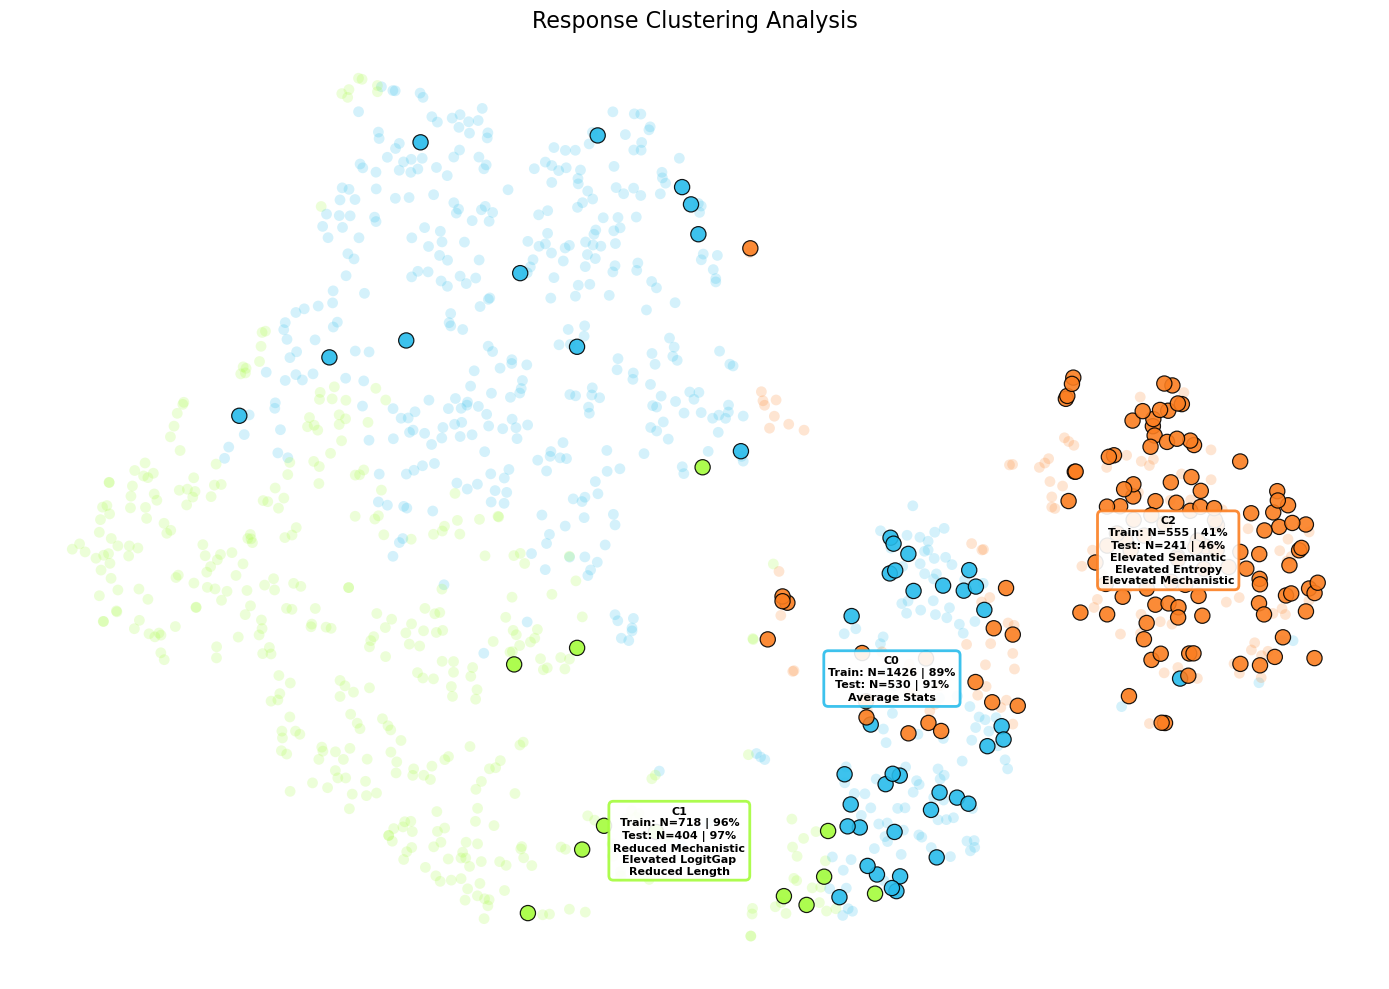

Generating Difficulty Stratification Plots...
Generating Stratified Plots for k=[0, 1, 2, 3, 4]...


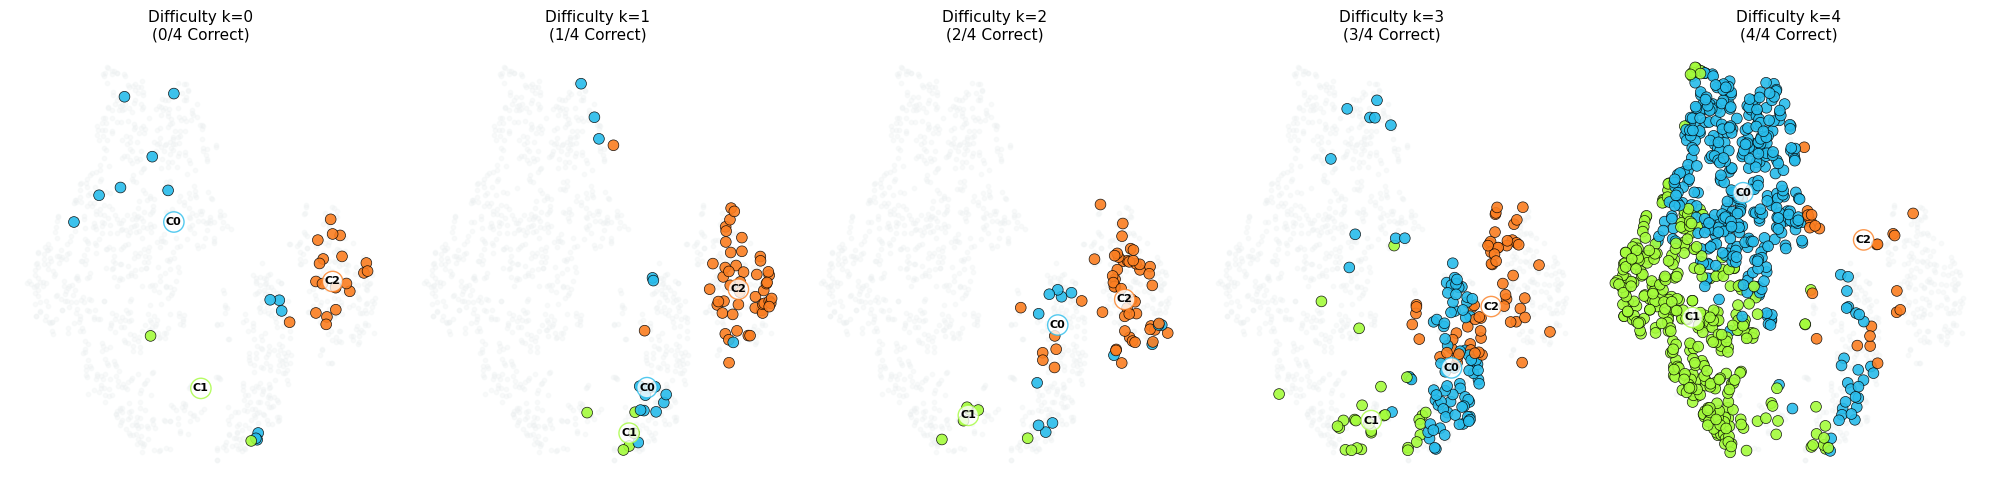

Generating Discrimination Bar Chart...


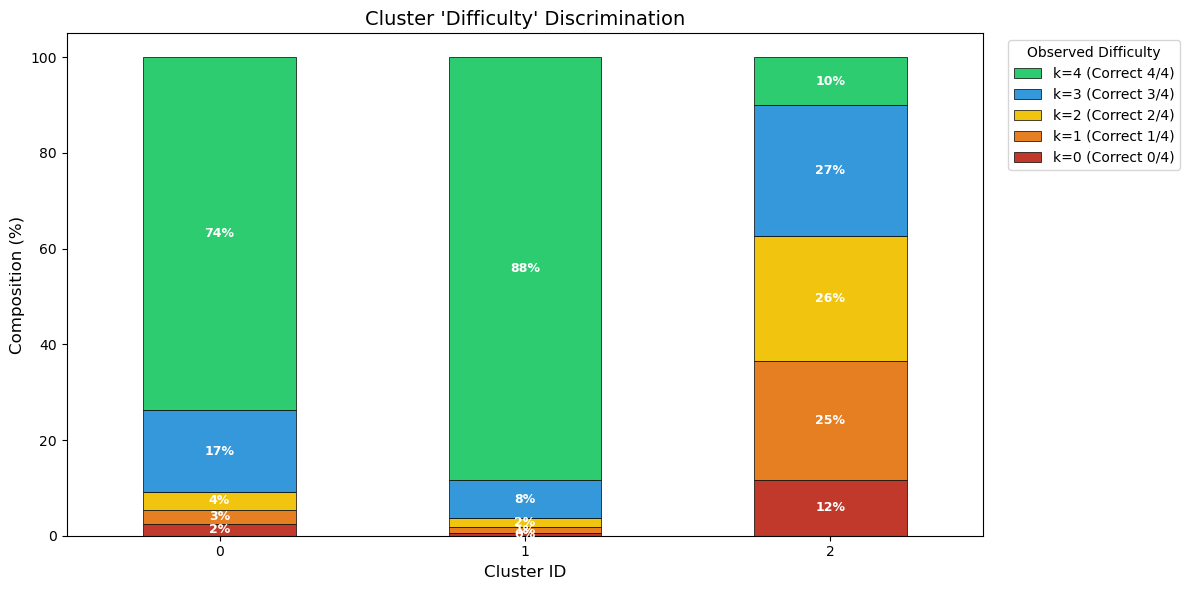


--- Pairwise Cluster Comparison (Same Question Overlap) ---


/Users/sadigulcelik/Documents/CompSci/ScalingLLM-2025-Fall/Uncertainty-Aware-Error-Detection-and-Recovery/analysis_utils.py:890: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_diff, subset=['Train_Diff', 'Test_Diff'])


,Pair,Train_N,Train_Diff,Test_N,Test_Diff
0,C0 (88.9%) vs C1 (96.2%),224,-0.4%,103,-3.1%
1,C0 (88.9%) vs C2 (41.3%),102,+23.7%,43,+29.5%
2,C1 (96.2%) vs C2 (41.3%),30,+13.3%,16,+20.8%


In [4]:
cluster_predictor = utils.run_failure_modes_dashboard(train_df, exp_info, features=["Entropy", "Length", "Mechanistic", "LogitGap", "Semantic", "Consistency"], test_df = test_df, min_clusters = 3)

In [5]:
cluster_predictor = utils.run_failure_modes_dashboard(train_df, exp_info, features=["Entropy", "Length", "Mechanistic", "LogitGap"], test_df = test_df, min_clusters = 5, plot = False)

logistic_predictor = utils.run_detailed_logistic_regression(train_df, features=["Entropy", "Length", "Mechanistic", "LogitGap"], test_df = test_df, plot = False)


heavy_cluster_predictor = utils.run_failure_modes_dashboard(train_df, exp_info, features=["Entropy", "Length", "Mechanistic", "LogitGap", "Semantic", "Consistency", "Heuristic"], test_df = test_df, min_clusters = 5, plot = False)



utils.run_expanded_comparison(
    train_df, 
    # Classifiers
    {'Logistic Regression': logistic_predictor},
    
    # Clusterers (Split them here)
    {
        'Cluster Baseline': cluster_predictor, 
        'Heavy Cluster Baseline': heavy_cluster_predictor 
    },
    
    # Metrics
    ["Entropy", "Length", "Mechanistic", "LogitGap", "Semantic", "Consistency", "Heuristic"], 
    test_df=test_df
)

Evaluated 10 models/features.


,Train AUROC,Train ECE,Train Brier (MSE),Train Log Loss,Train Accuracy,Train F1-Score,Train Precision,Train Recall,Test AUROC,Test ECE,Test Brier (MSE),Test Log Loss,Test Accuracy,Test F1-Score,Test Precision,Test Recall
Model,,,,,,,,,,,,,,,,
Logistic Regression,0.7903,0.2356,0.1804,0.5525,0.7551,0.8375,0.9063,0.7783,0.8184,0.2468,0.1721,0.5271,0.7583,0.8424,0.9313,0.7690
Entropy,0.7525,0.0391,0.1339,0.4384,0.8166,0.8979,0.8184,0.9945,0.8114,0.0464,0.1135,0.3668,0.8468,0.9162,0.8475,0.9970
Length,0.6380,0.3401,0.2660,0.7740,0.5569,0.6595,0.8746,0.5293,0.6156,0.3488,0.2620,0.7426,0.5787,0.6969,0.8808,0.5765
Mechanistic,0.7508,0.5867,0.4833,1.2803,0.1904,0.0046,0.7143,0.0023,0.7667,0.6047,0.4861,1.2594,0.1626,0.0061,1.0000,0.0030
LogitGap,0.6349,0.6258,0.6722,5.3391,0.1997,0.0279,0.9118,0.0142,0.6298,0.6503,0.6877,5.3267,0.1745,0.0358,0.9474,0.0182
Semantic,0.8648,0.0623,0.1072,1.2229,0.8474,0.9052,0.9111,0.8995,0.8737,0.0680,0.1001,0.9335,0.8681,0.9215,0.9211,0.9220
Consistency,0.7085,0.0896,0.1522,0.4817,0.8110,0.8955,0.8114,0.9991,0.7491,0.0746,0.1297,0.4184,0.8400,0.9130,0.8400,1.0000
Heuristic,0.5173,0.3018,0.2596,0.7305,0.5232,0.6456,0.8122,0.5356,0.5565,0.3232,0.2490,0.6911,0.5472,0.6736,0.8538,0.5562
Cluster Baseline_Prob,0.7380,0.0000,0.1291,0.4121,0.8344,0.9045,0.8492,0.9676,0.7398,0.2106,0.1797,1.4441,0.5438,0.6369,0.9611,0.4762


,Train AUROC,Train ECE,Train Brier (MSE),Train Log Loss,Train Accuracy,Train F1-Score,Train Precision,Train Recall,Test AUROC,Test ECE,Test Brier (MSE),Test Log Loss,Test Accuracy,Test F1-Score,Test Precision,Test Recall
Model,,,,,,,,,,,,,,,,
Logistic Regression,0.790269,2.356488e-01,0.180448,0.552518,0.755094,0.837472,0.906333,0.778336,0.818438,0.246766,0.172051,0.527086,0.758298,0.842397,0.931288,0.768997
Entropy,0.752545,3.905571e-02,0.133914,0.438359,0.816599,0.897875,0.818353,0.994516,0.811399,0.046354,0.113480,0.366789,0.846809,0.916201,0.847545,0.996960
Length,0.638044,3.401117e-01,0.266049,0.774024,0.556873,0.659453,0.874622,0.529250,0.615580,0.348845,0.261988,0.742607,0.578723,0.696877,0.880805,0.576494
Mechanistic,0.750782,5.866976e-01,0.483349,1.280309,0.190441,0.004556,0.714286,0.002285,0.766690,0.604732,0.486137,1.259381,0.162553,0.006061,1.000000,0.003040
LogitGap,0.634945,6.258090e-01,0.672154,5.339125,0.199704,0.027903,0.911765,0.014168,0.629751,0.650338,0.687701,5.326708,0.174468,0.035785,0.947368,0.018237
Semantic,0.864828,6.228552e-02,0.107204,1.222943,0.847351,0.905244,0.911111,0.899452,0.873677,0.067956,0.100114,0.933484,0.868085,0.921519,0.921053,0.921986
Consistency,0.708460,8.962063e-02,0.152249,0.481728,0.811041,0.895535,0.811433,0.999086,0.749105,0.074640,0.129682,0.418356,0.840000,0.913043,0.840000,1.000000
Heuristic,0.517345,3.017808e-01,0.259623,0.730517,0.523157,0.645552,0.812197,0.535649,0.556490,0.323218,0.248977,0.691068,0.547234,0.673620,0.853810,0.556231
Cluster Baseline_Prob,0.738003,3.080982e-17,0.129093,0.412145,0.834383,0.904508,0.849178,0.967550,0.739761,0.210636,0.179656,1.444118,0.543830,0.636856,0.961145,0.476190


Metric,Shift (Test),Train μ,Test μ,Test σ,Vis
Entropy,-1.53 SD,0.708,0.714,0.06,
Semantic,-2.22 SD,0.266,0.299,0.20,
Metric,Shift (Test),Train μ,Test μ,Test σ,Vis
Entropy,+0.38 SD,0.909,0.912,0.03,
Semantic,+0.00 SD,1.000,1.000,0.00,
Metric,Shift (Test),Train μ,Test μ,Test σ,Vis
Entropy,-0.12 SD,0.865,0.861,0.05,
Semantic,-1.55 SD,0.469,0.512,0.16,
Metric,Shift (Test),Train μ,Test μ,Test σ,Vis
Entropy,-0.71 SD,0.803,0.800,0.05,


Generating t-SNE on Train & Test Analysis...


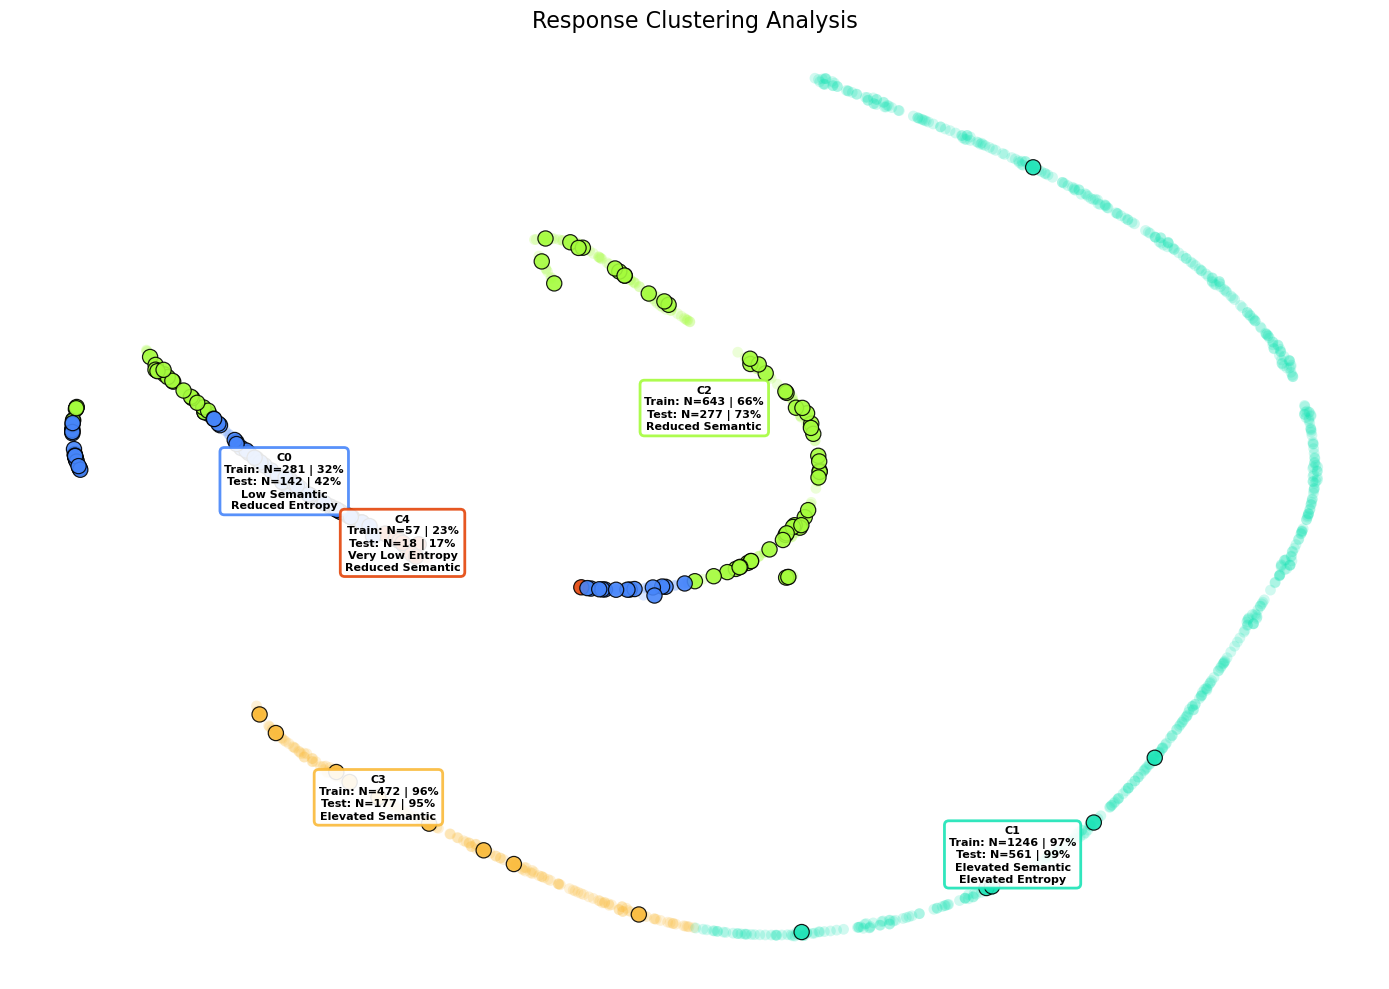

Generating Difficulty Stratification Plots...
Generating Stratified Plots for k=[0, 1, 2, 3, 4]...


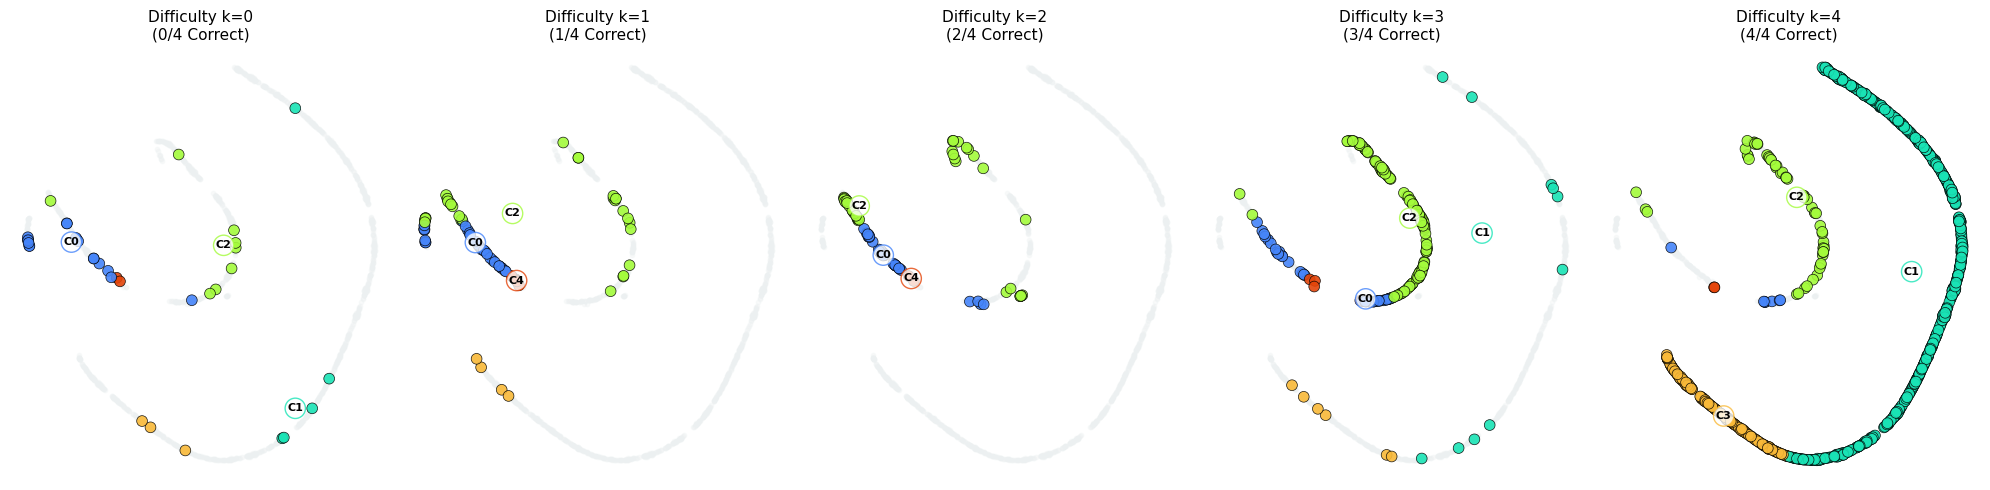

Generating Discrimination Bar Chart...


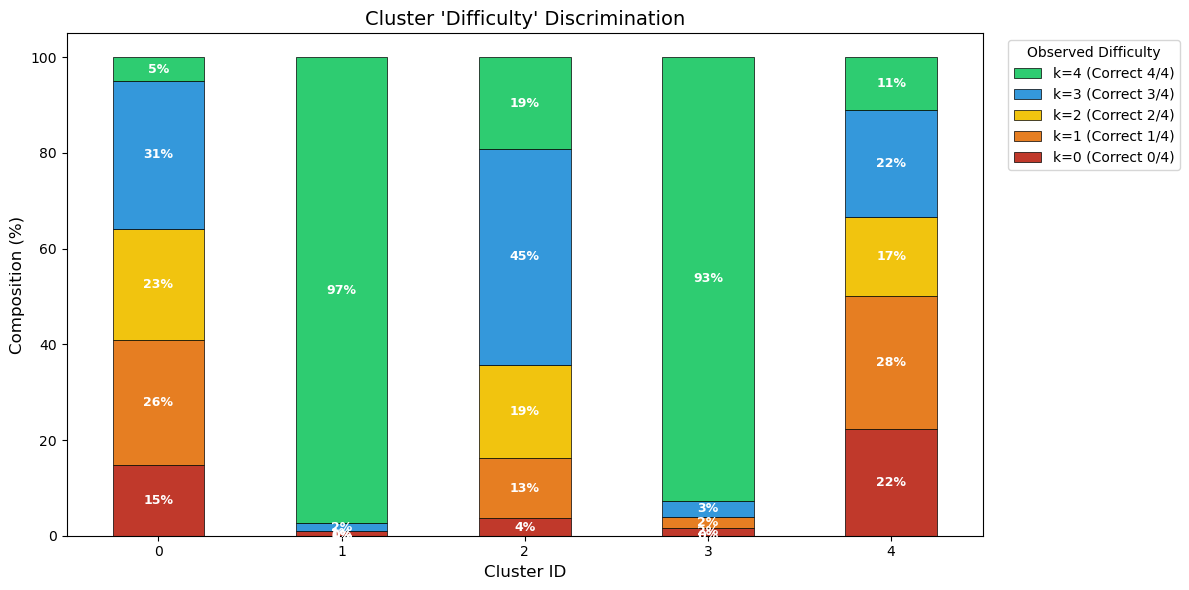


--- Pairwise Cluster Comparison (Same Question Overlap) ---


/Users/sadigulcelik/Documents/CompSci/ScalingLLM-2025-Fall/Uncertainty-Aware-Error-Detection-and-Recovery/analysis_utils.py:890: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_diff, subset=['Train_Diff', 'Test_Diff'])


,Pair,Train_N,Train_Diff,Test_N,Test_Diff
0,C0 (32.0%) vs C2 (65.6%),105,-28.3%,49,-23.5%
1,C0 (32.0%) vs C4 (22.8%),36,+18.1%,9,+50.0%
2,C1 (97.1%) vs C3 (96.0%),217,+0.8%,78,+2.4%
3,C1 (97.1%) vs C4 (22.8%),4,+25.0%,1,+0.0%
4,C2 (65.6%) vs C4 (22.8%),18,+60.2%,7,+100.0%
5,C3 (96.0%) vs C4 (22.8%),4,+25.0%,2,+0.0%


In [6]:
cluster_predictor = utils.run_failure_modes_dashboard(train_df, exp_info, features=["Entropy", "Semantic"], test_df = test_df, min_clusters = 5)

### Full Logistic Regression Analysis

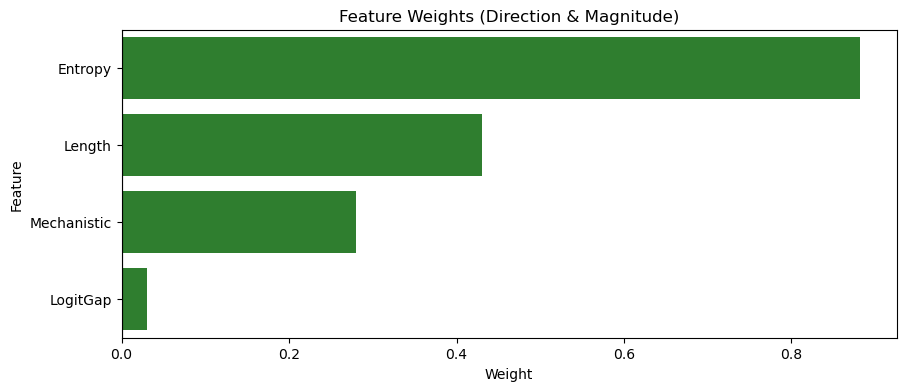

              precision    recall  f1-score   support

           0       0.37      0.70      0.48       188
           1       0.93      0.77      0.84       987

    accuracy                           0.76      1175
   macro avg       0.65      0.74      0.66      1175
weighted avg       0.84      0.76      0.78      1175



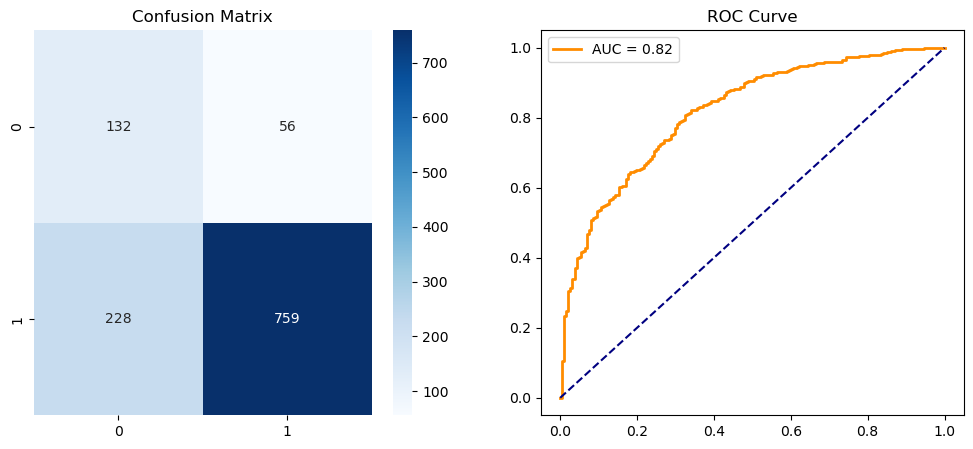

### Full Logistic Regression Analysis

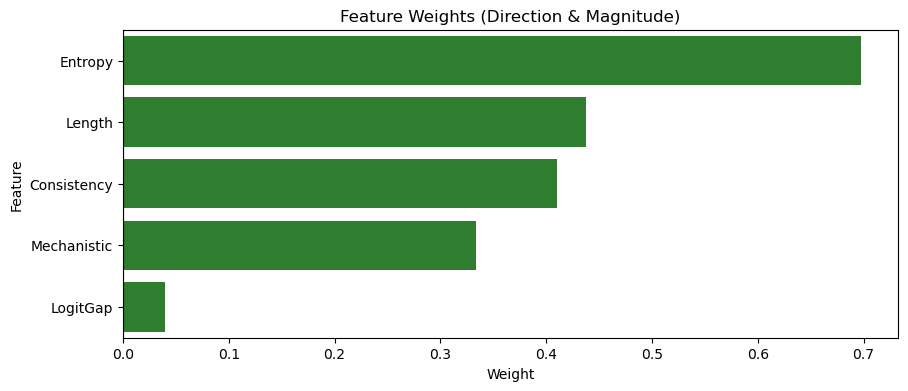

              precision    recall  f1-score   support

           0       0.38      0.73      0.50       188
           1       0.94      0.77      0.85       987

    accuracy                           0.77      1175
   macro avg       0.66      0.75      0.68      1175
weighted avg       0.85      0.77      0.79      1175



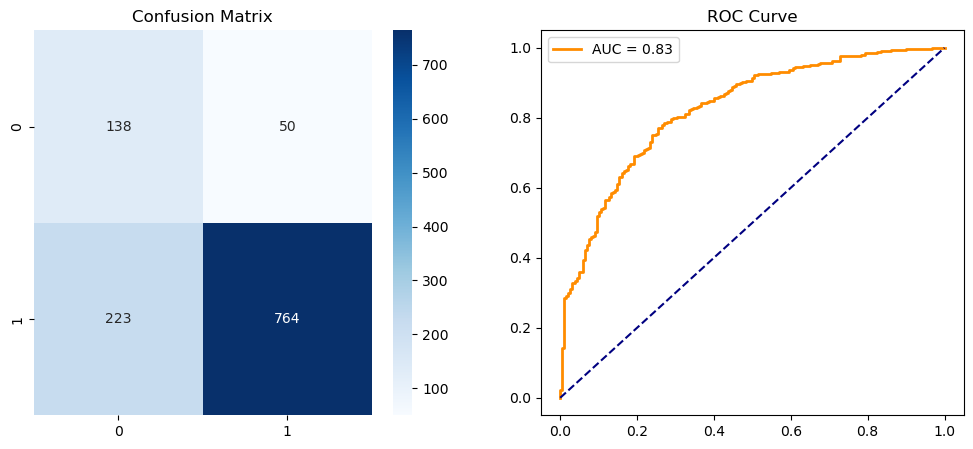

Metric,Shift (Test),Train μ,Test μ,Test σ,Vis
Entropy,-2.36 SD,0.624,0.629,0.12,
LogitGap,-0.15 SD,0.038,0.037,0.05,
Mechanistic,-1.26 SD,0.117,0.111,0.05,
Length,+0.03 SD,0.479,0.501,0.21,
Consistency,-1.24 SD,0.795,0.828,0.06,
Metric,Shift (Test),Train μ,Test μ,Test σ,Vis
Entropy,+0.33 SD,0.907,0.908,0.04,
LogitGap,+0.33 SD,0.087,0.091,0.06,
Mechanistic,+1.13 SD,0.306,0.315,0.05,
Length,+0.38 SD,0.552,0.564,0.11,


Generating t-SNE on Train & Test Analysis...


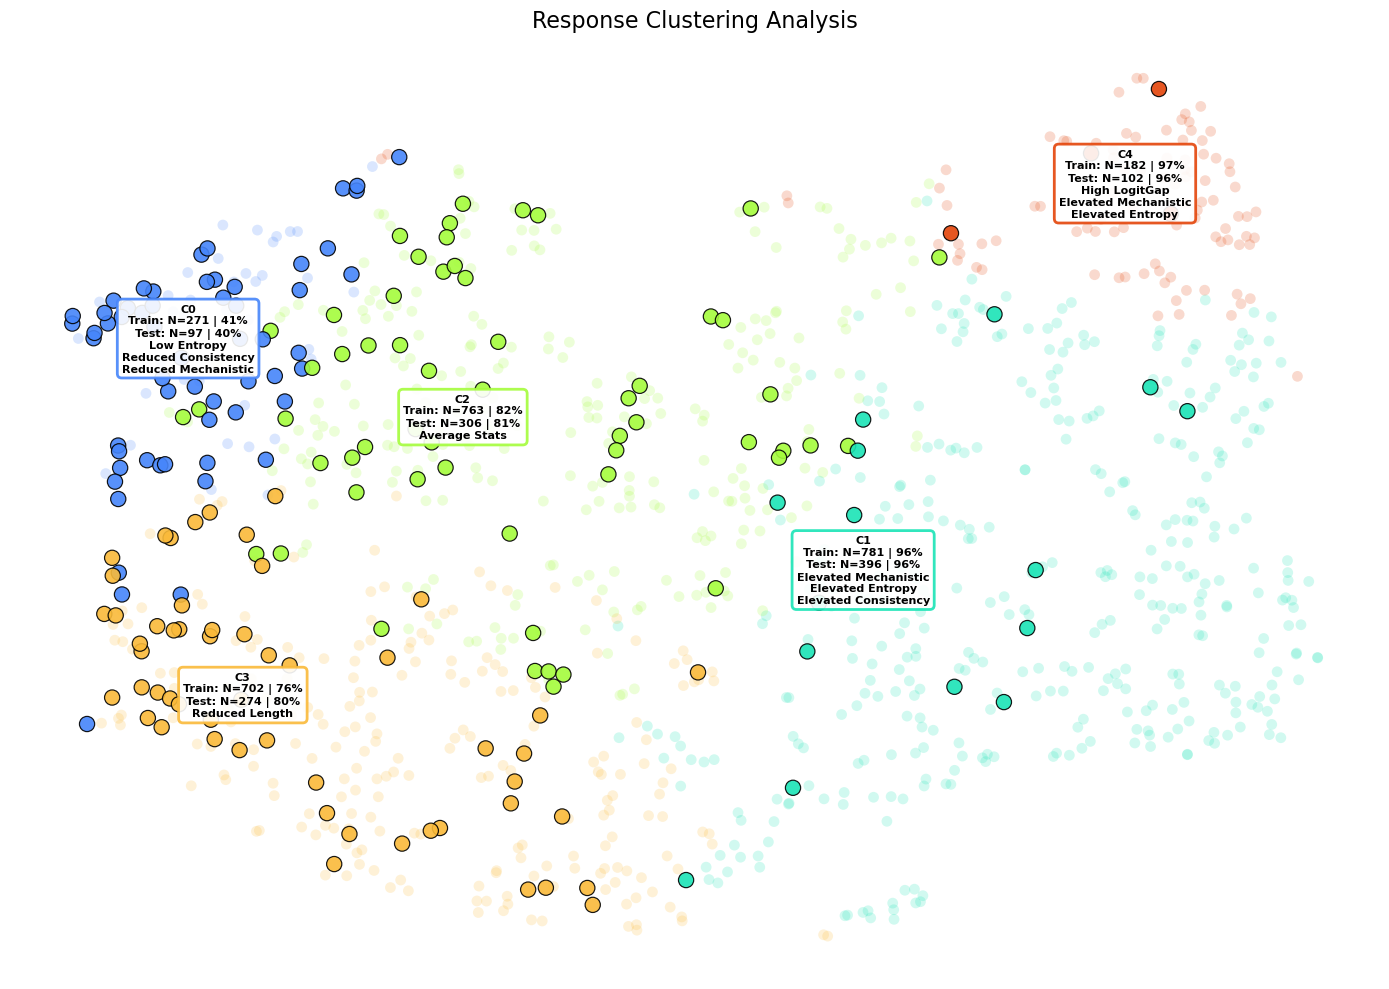

Generating Difficulty Stratification Plots...
Generating Stratified Plots for k=[0, 1, 2, 3, 4]...


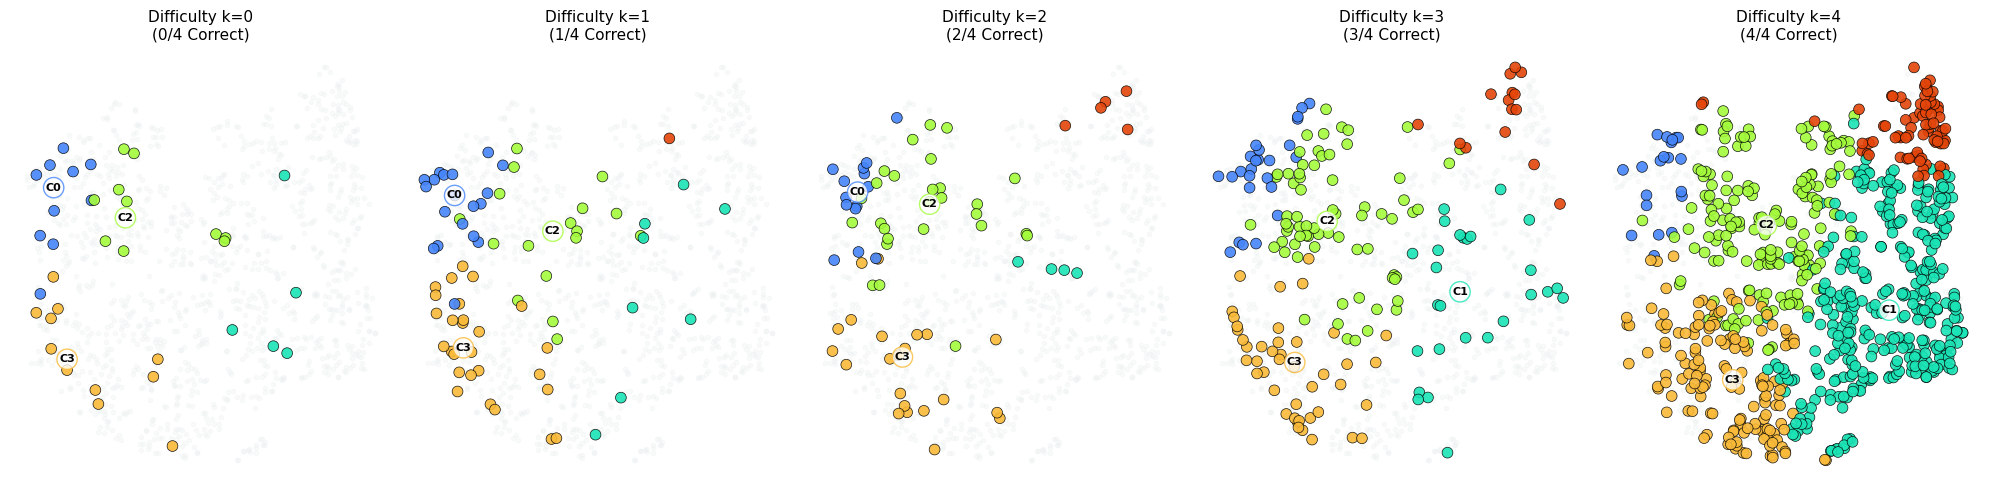

Generating Discrimination Bar Chart...


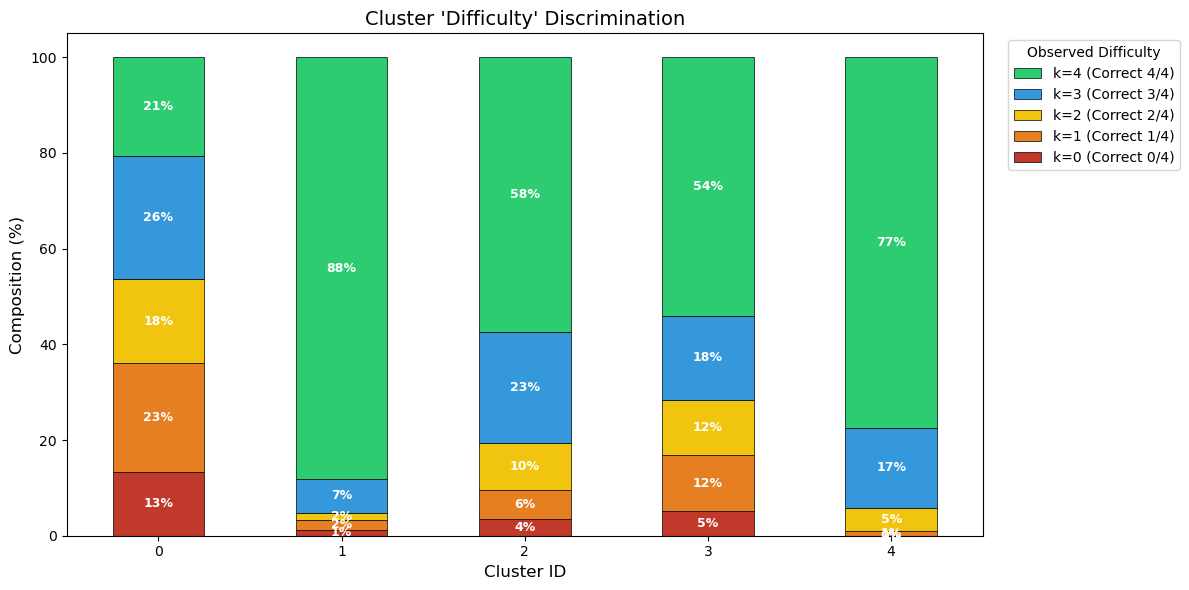


--- Pairwise Cluster Comparison (Same Question Overlap) ---


/Users/sadigulcelik/Documents/CompSci/ScalingLLM-2025-Fall/Uncertainty-Aware-Error-Detection-and-Recovery/analysis_utils.py:890: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_diff, subset=['Train_Diff', 'Test_Diff'])


,Pair,Train_N,Train_Diff,Test_N,Test_Diff
0,C0 (40.6%) vs C1 (95.6%),23,-10.9%,8,-50.0%
1,C0 (40.6%) vs C2 (81.7%),77,-27.5%,41,-23.2%
2,C0 (40.6%) vs C3 (75.8%),69,-25.4%,27,-21.6%
3,C0 (40.6%) vs C4 (96.7%),9,-61.1%,6,-61.1%
4,C1 (95.6%) vs C2 (81.7%),159,+3.0%,52,+9.6%
5,C1 (95.6%) vs C3 (75.8%),85,+2.7%,28,+2.4%
6,C1 (95.6%) vs C4 (96.7%),87,+0.0%,56,+1.2%
7,C2 (81.7%) vs C3 (75.8%),159,+0.8%,61,-10.1%
8,C2 (81.7%) vs C4 (96.7%),63,-4.8%,25,-9.3%
9,C3 (75.8%) vs C4 (96.7%),33,-9.6%,15,-10.0%


In [7]:


metrics_to_use = ['Entropy', 'LogitGap', 'Mechanistic','Length'] # 'Consistency', 

logistic_predictor = utils.run_detailed_logistic_regression(train_df, features=metrics_to_use, test_df = test_df)

logistic_predictor_with_consistency = utils.run_detailed_logistic_regression(train_df, features=metrics_to_use + ["Consistency"], test_df = test_df)



cluster_predictor_with_consistency = utils.run_failure_modes_dashboard(train_df, exp_info, features=metrics_to_use + ["Consistency"], test_df = test_df, min_clusters = 5)

In [8]:
# 1. Capture Logistic Fusion Probabilities (Index 0)

for sdf in [df, train_df, test_df]:
    sdf['Logistic_Fusion'], _ = logistic_predictor(sdf)

    # 1. Capture Logistic Fusion Probabilities (Index 0)
    sdf['Logistic_Fusion_Consistency'], _ = logistic_predictor_with_consistency(sdf)

    # 2. Capture Cluster Labels (Index 1)
    _, sdf['Cluster_Label'] = cluster_predictor(sdf)

    # 3. (Optional) Capture Cluster Confidence if needed
    sdf['Cluster_Conf'], _ = cluster_predictor(sdf)

        # 2. Capture Cluster Labels (Index 1)
    _, sdf['Cluster_Label_Consistency'] = cluster_predictor_with_consistency(sdf)

    # 3. (Optional) Capture Cluster Confidence if needed
    sdf['Cluster_Conf_Consistency'], _ = cluster_predictor_with_consistency(sdf)

    # Verify
    print(sdf[['Logistic_Fusion', 'Cluster_Label']].head())

   Logistic_Fusion Cluster_Label
0              1.0     Cluster 4
1              1.0     Cluster 4
2              1.0     Cluster 4
3              1.0     Cluster 4
4              1.0     Cluster 4
   Logistic_Fusion Cluster_Label
0         0.817988     Cluster 2
1         0.896099     Cluster 2
2         0.892788     Cluster 2
3         0.897047     Cluster 2
4         0.516819     Cluster 2
    Logistic_Fusion Cluster_Label
24         0.723067     Cluster 1
25         0.732460     Cluster 1
26         0.719095     Cluster 1
27         0.765185     Cluster 1
40         0.677524     Cluster 1


In [9]:
utils.run_comparison_dashboard(train_df, logistic_predictor, cluster_predictor, metrics_to_use, test_df = test_df)

,Train AUROC,Train ECE,Train MSE,Test AUROC,Test ECE,Test MSE
Model,,,,,,
Logistic Fusion,0.7903,0.2356,0.1804,0.8184,0.2468,0.1721
Cluster Baseline,0.8640,0.0000,0.0998,0.8785,0.0367,0.0935
Entropy,0.7525,0.0391,0.1339,0.8114,0.0464,0.1135
LogitGap,0.6349,0.6258,0.6722,0.6298,0.6503,0.6877
Mechanistic,0.7508,0.5867,0.4833,0.7667,0.6047,0.4861
Length,0.6380,0.3401,0.2660,0.6156,0.3488,0.2620


Model,Mn,Rg
Logistic Fusion,0.27,0.82
Cluster Baseline,0.32,0.00
Entropy,0.71,0.28
LogitGap,0.05,0.45
Mechanistic,0.14,0.55
Length,0.48,0.93
Model,Mn,Rg
Logistic Fusion,0.74,0.62
Cluster Baseline,0.97,0.00
Entropy,0.91,0.14


In [10]:
utils.run_comparison_dashboard(train_df, logistic_predictor_with_consistency, cluster_predictor_with_consistency, metrics_to_use + ["Consistency"], test_df = test_df)

,Train AUROC,Train ECE,Train MSE,Test AUROC,Test ECE,Test MSE
Model,,,,,,
Logistic Fusion,0.7903,0.2356,0.1804,0.8184,0.2468,0.1721
Cluster Baseline,0.8640,0.0000,0.0998,0.8785,0.0367,0.0935
Entropy,0.7525,0.0391,0.1339,0.8114,0.0464,0.1135
LogitGap,0.6349,0.6258,0.6722,0.6298,0.6503,0.6877
Mechanistic,0.7508,0.5867,0.4833,0.7667,0.6047,0.4861
Length,0.6380,0.3401,0.2660,0.6156,0.3488,0.2620
Consistency,0.7085,0.0896,0.1522,0.7491,0.0746,0.1297


Model,Mn,Rg
Logistic Fusion,0.27,0.82
Cluster Baseline,0.32,0.00
Entropy,0.71,0.28
LogitGap,0.05,0.45
Mechanistic,0.14,0.55
Length,0.48,0.93
Consistency,0.86,0.28
Model,Mn,Rg
Logistic Fusion,0.74,0.62
Cluster Baseline,0.97,0.00


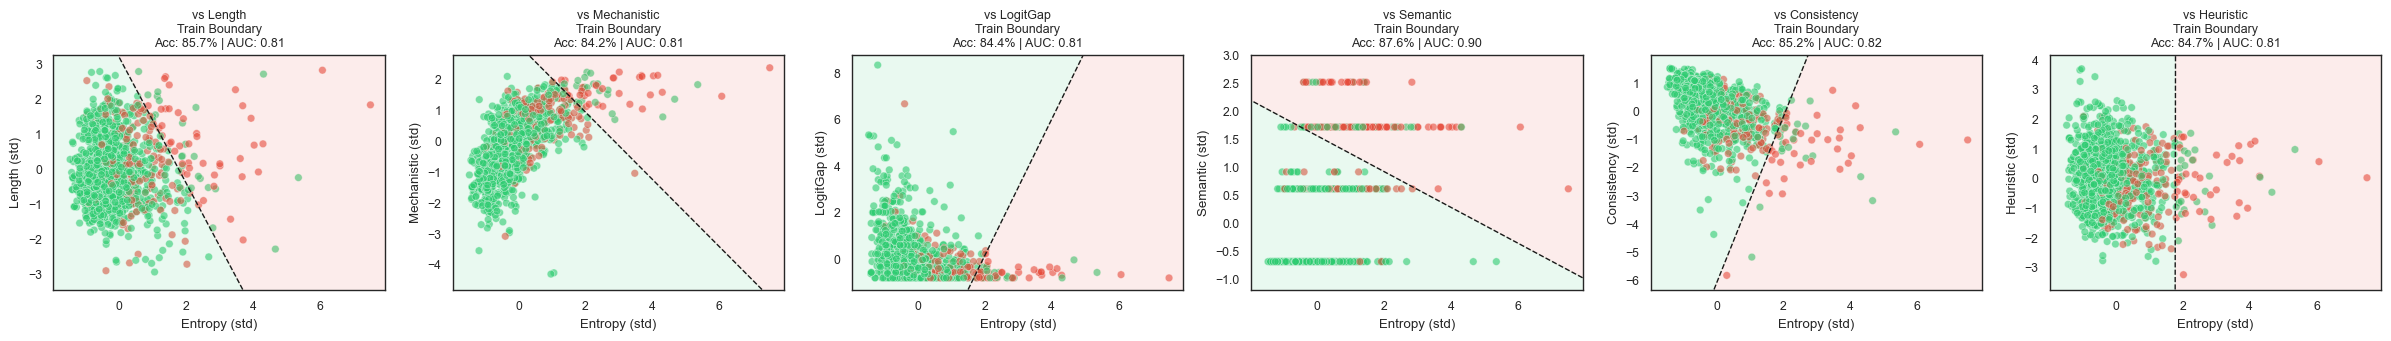

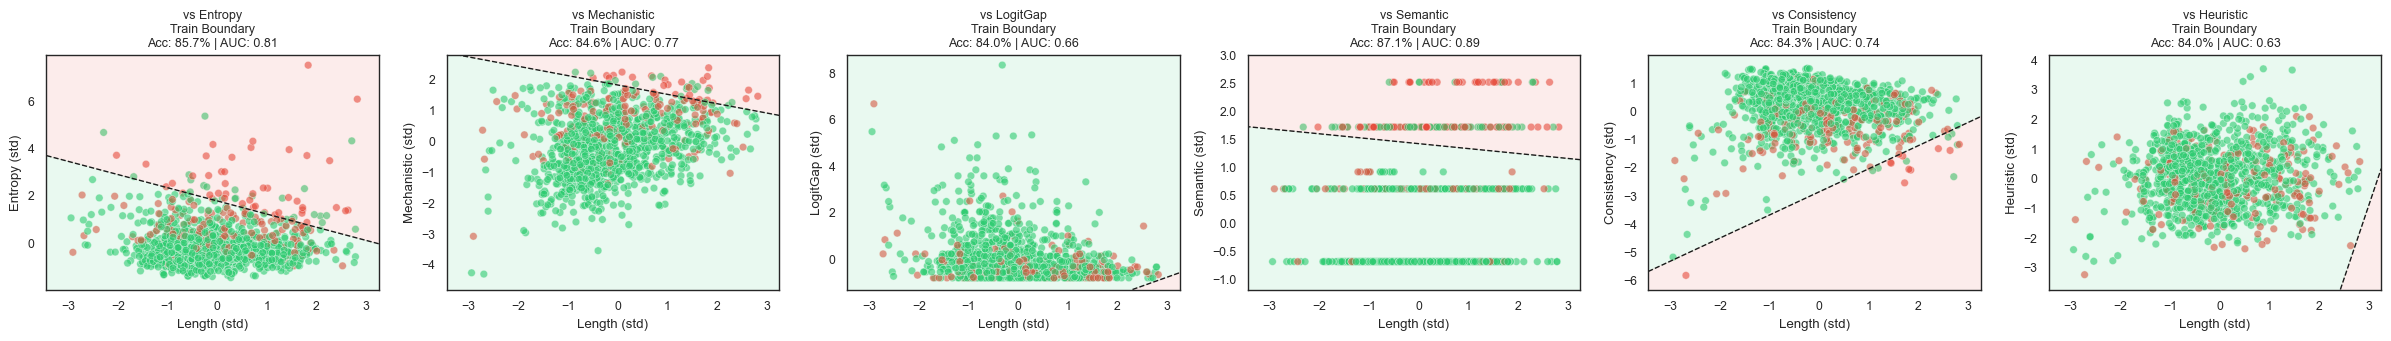

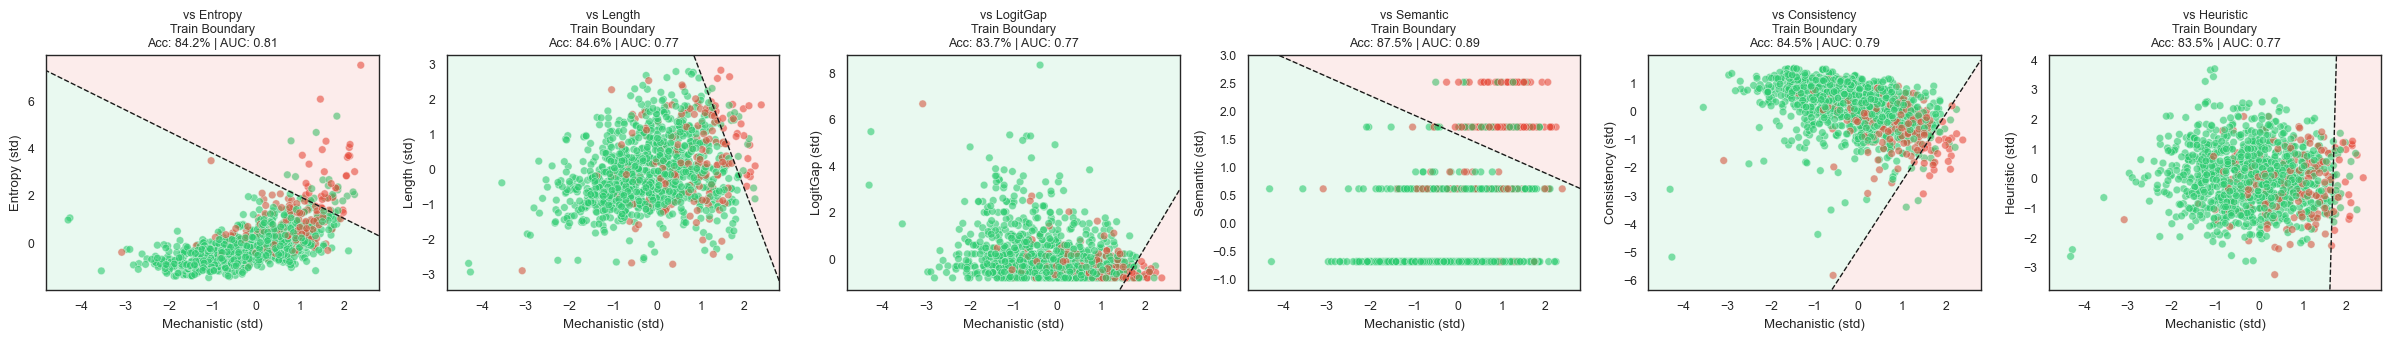

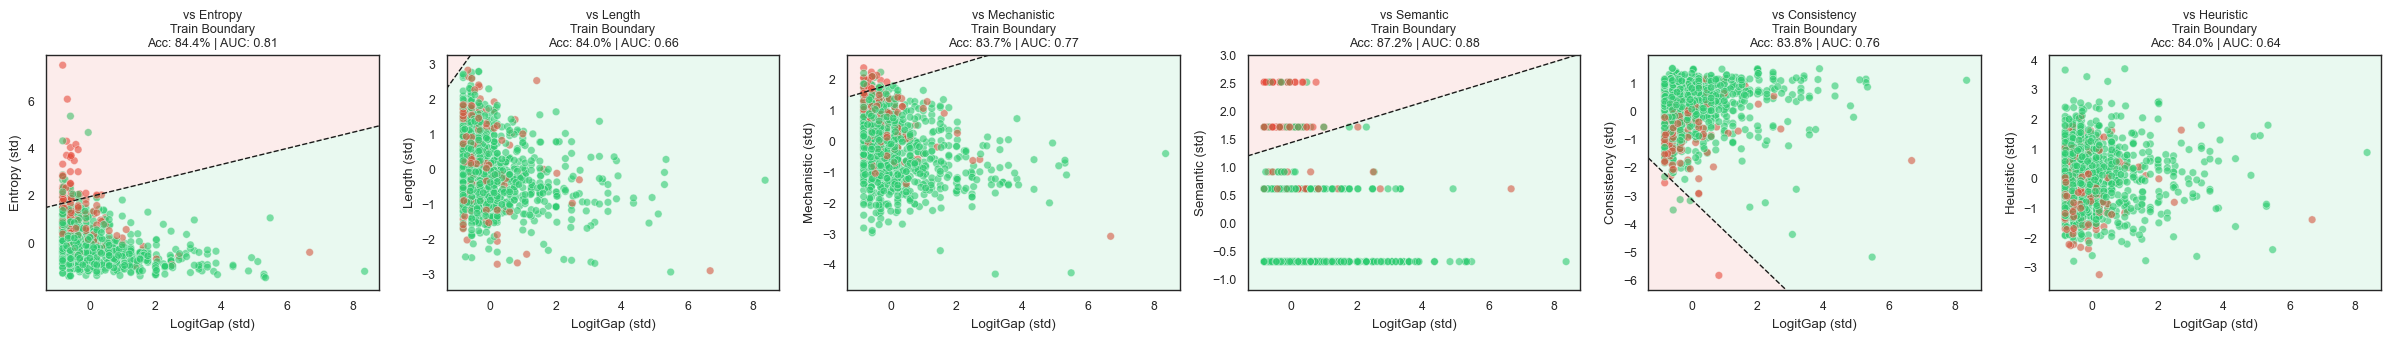

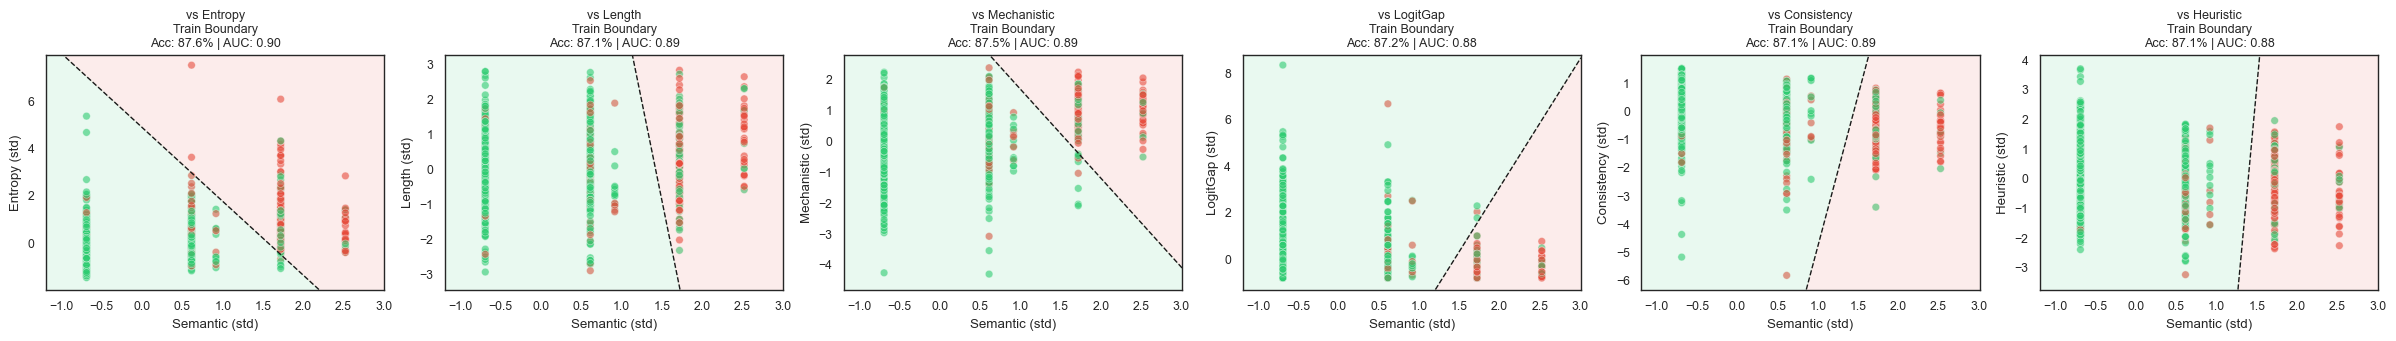

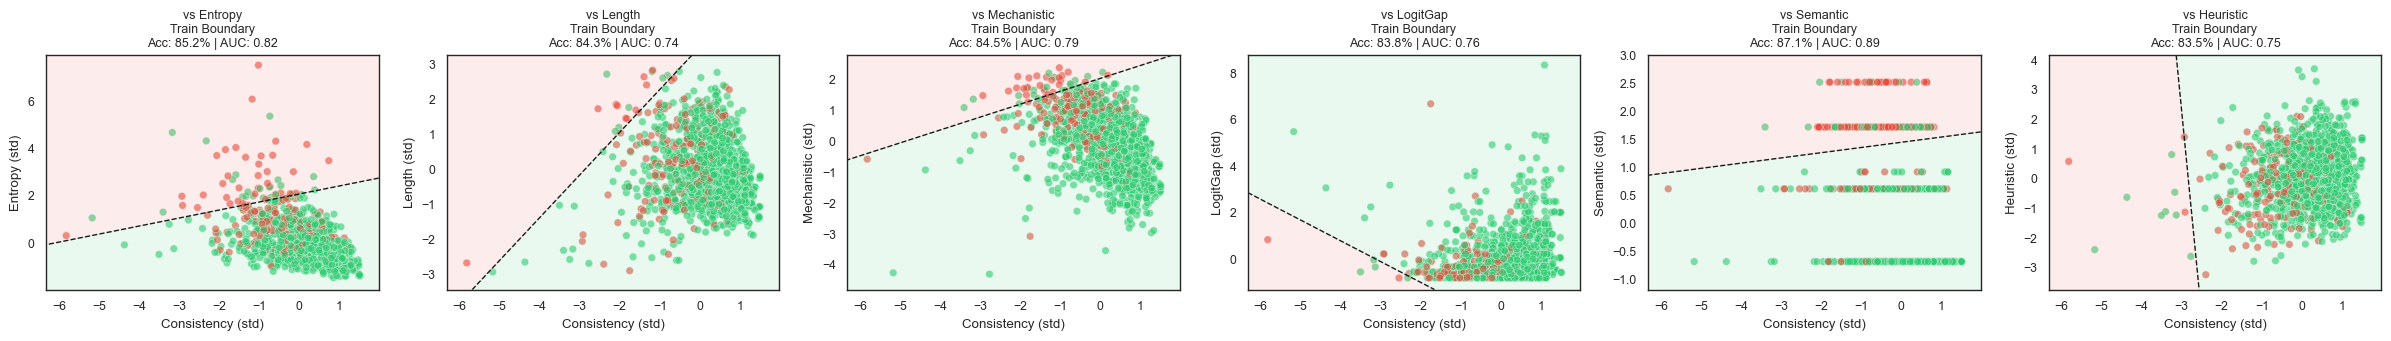

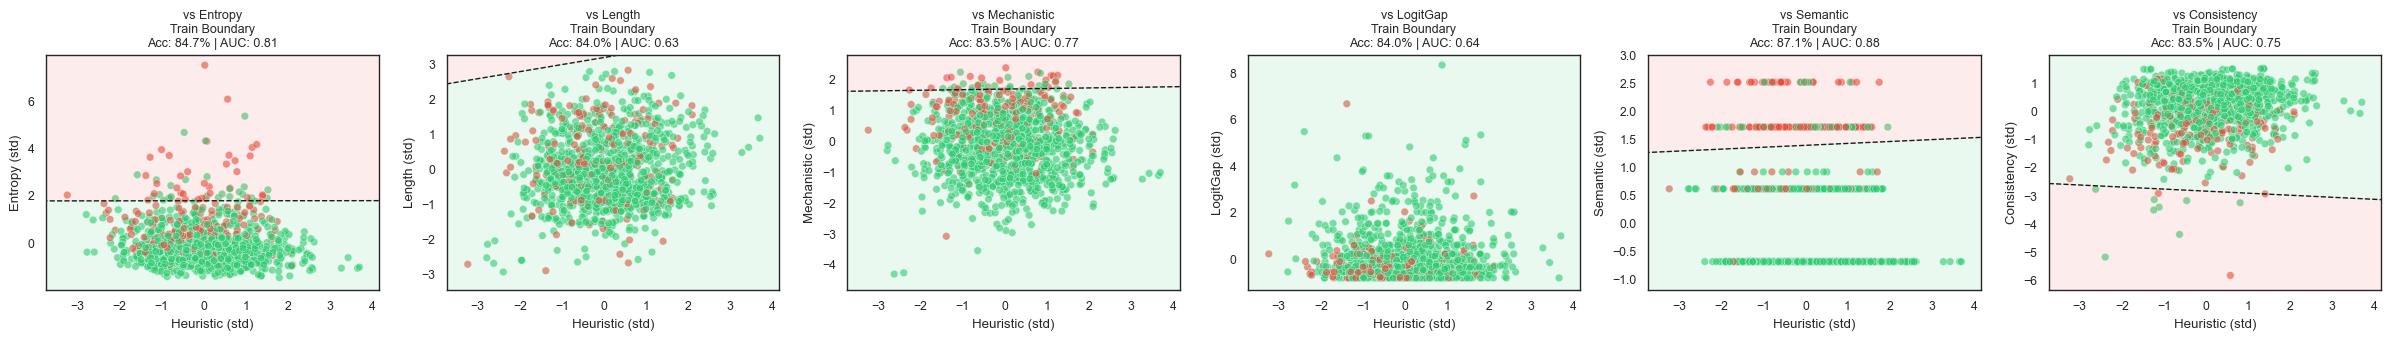

{'Entropy': <analysis_utils.PredictorArtifact at 0x3644dda10>,
 'Length': <analysis_utils.PredictorArtifact at 0x35ff37150>,
 'Mechanistic': <analysis_utils.PredictorArtifact at 0x364a32cd0>,
 'LogitGap': <analysis_utils.PredictorArtifact at 0x364c9d650>,
 'Semantic': <analysis_utils.PredictorArtifact at 0x364558ad0>,
 'Consistency': <analysis_utils.PredictorArtifact at 0x35102be90>,
 'Heuristic': <analysis_utils.PredictorArtifact at 0x364317610>}

In [11]:
utils.run_full_analysis(train_df,metrics, test_df = test_df)

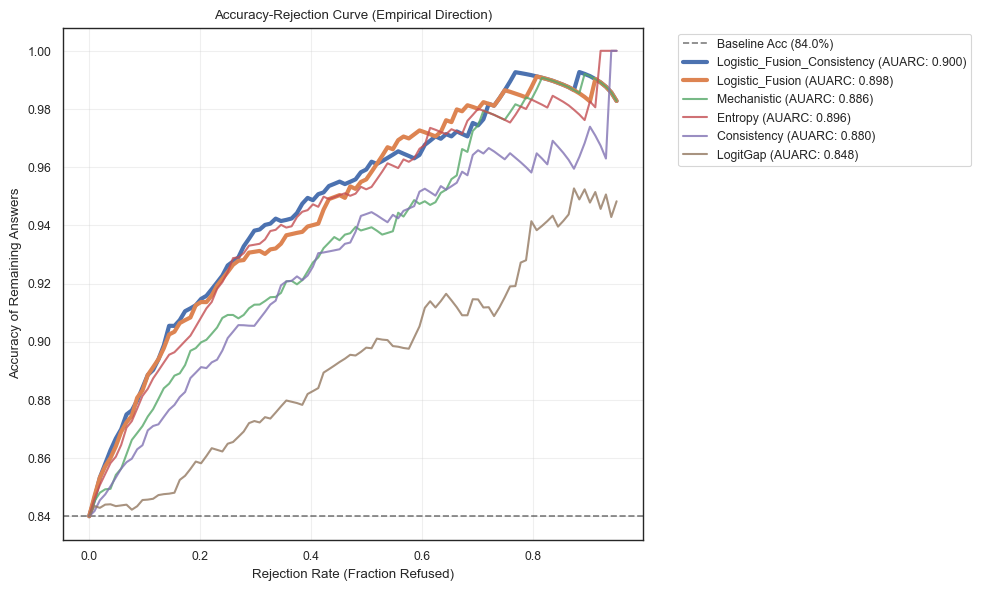

In [12]:
cluster_accs = df.groupby('Cluster_Label')['Correct'].mean()
df['Cluster Baseline'] = df['Cluster_Label'].map(cluster_accs)

metrics_to_plot = ["Logistic_Fusion_Consistency", "Logistic_Fusion", "Mechanistic", "Entropy", "Consistency", "LogitGap"] 

utils.plot_auarc_analysis(test_df, metrics_to_plot)

In [13]:
df.keys()

Index(['result_id', 'question_id_external', 'question_text', 'gold_answer',
       'predicted_answer', 'full_trace_text', 'is_correct', 'Entropy',
       'LogitGap', 'Heuristic', 'Mechanistic', 'Consistency',
       'similarity_vector', 'uq_tokens', 'uq_mech_trace', 'uq_entropy_trace',
       'uq_logit_gap_trace', 'Correct', 'Semantic', 'Length', 'Entropy_Z',
       'LogitGap_Z', 'Heuristic_Z', 'Mechanistic_Z', 'Consistency_Z',
       'Semantic_Z', 'Length_Z', 'null', 'Logistic_Fusion',
       'Logistic_Fusion_Consistency', 'Cluster_Label', 'Cluster_Conf',
       'Cluster_Label_Consistency', 'Cluster_Conf_Consistency',
       'Cluster Baseline'],
      dtype='object')

In [14]:
utils.analyze_outlier_clusters(df)

🔍 Analyzing 63 subsets on Train (n=2699) vs Test (n=1175)...


,Feature,Impact
4,Length,-2.73%
1,LogitGap,-1.24%
2,Heuristic,0.01%
5,Consistency,1.95%
3,Mechanistic,2.77%
0,Entropy,5.30%


,Size,Features,Acc_Best,Acc_Worst,Gap
10,2,"Entropy, Consistency",89.0%,74.9%,14.0%
27,3,"Entropy, Heuristic, Consistency",89.0%,74.9%,14.0%
29,3,"Entropy, Mechanistic, Consistency",89.0%,74.9%,14.0%
48,4,"Entropy, Heuristic, Mechanistic, Consistency",89.0%,74.9%,14.0%
6,2,"Entropy, LogitGap",89.3%,75.9%,13.4%
21,3,"Entropy, LogitGap, Heuristic",89.3%,75.9%,13.4%
0,1,Entropy,89.0%,75.6%,13.4%
57,5,"Entropy, LogitGap, Heuristic, Mechanistic, Consistency",88.0%,74.9%,13.0%
45,4,"Entropy, LogitGap, Mechanistic, Consistency",88.0%,74.9%,13.0%
7,2,"Entropy, Heuristic",89.0%,75.9%,13.0%


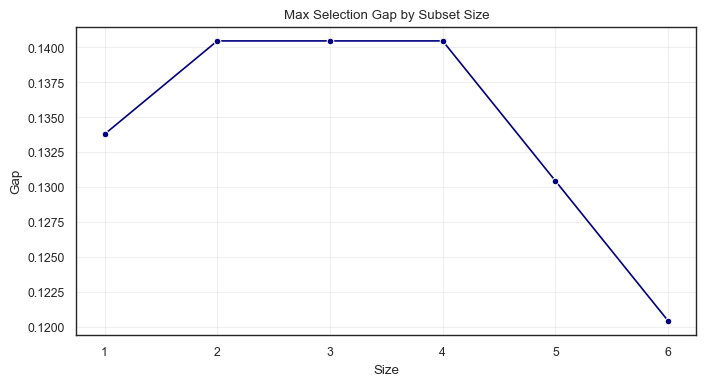

In [15]:
def analyze_feature_redundancy(train_df, test_df):
    import itertools
    import numpy as np
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler
    from IPython.display import display, HTML

    # 1. Configuration & Pre-processing
    features = ['Entropy', 'LogitGap', 'Heuristic', 'Mechanistic', 'Length', "Consistency"]
    group_col = 'question_id_external' if 'question_id_external' in test_df.columns else 'question_text'
    
    # Scale based on TRAIN, apply to BOTH
    scaler = StandardScaler().fit(train_df[features].fillna(0))
    X_train = pd.DataFrame(scaler.transform(train_df[features].fillna(0)), columns=features, index=train_df.index)
    X_test = pd.DataFrame(scaler.transform(test_df[features].fillna(0)), columns=features, index=test_df.index)
    y_train = train_df['Correct']

    # Filter TEST set for multi-answer questions only
    mask_eval = test_df.groupby(group_col)[group_col].transform('count') > 1
    eval_df = test_df.loc[mask_eval, [group_col, 'Correct']].copy()
    
    if eval_df.empty: return print("⚠️ No multi-answer questions in Test DF.")

    print(f"🔍 Analyzing {2**len(features)-1} subsets on Train (n={len(train_df)}) vs Test (n={len(eval_df)})...")
    
    # 2. Brute-Force Search
    results = []
    # Generate all non-empty subsets
    subsets = itertools.chain.from_iterable(itertools.combinations(features, r) for r in range(1, len(features)+1))

    for subset in subsets:
        cols = list(subset)
        
        # Fit on TRAIN
        clf = LogisticRegression(class_weight='balanced', random_state=42, solver='liblinear')
        clf.fit(X_train[cols], y_train)
        
        # Predict on TEST
        eval_df['probs'] = clf.predict_proba(X_test.loc[eval_df.index, cols])[:, 1]
        
        # Identify Best/Worst candidates per question
        g = eval_df.groupby(group_col)['probs']
        best_idx, worst_idx = g.idxmax(), g.idxmin()
        
        # Filter: Model must distinguish items (Prob_Best != Prob_Worst)
        valid = eval_df.loc[best_idx, 'probs'].values != eval_df.loc[worst_idx, 'probs'].values
        
        if valid.any():
            acc_best = eval_df.loc[best_idx[valid], 'Correct'].mean()
            acc_worst = eval_df.loc[worst_idx[valid], 'Correct'].mean()
            results.append({
                'Size': len(cols), 'Features': ", ".join(cols),
                'Acc_Best': acc_best, 'Acc_Worst': acc_worst, 'Gap': acc_best - acc_worst
            })

    # 3. Aggregation
    res_df = pd.DataFrame(results).sort_values('Gap', ascending=False)
    
    # Impact Analysis: Gap (With Feature) - Gap (Without Feature)
    impact_data = []
    for f in features:
        mask = res_df['Features'].str.contains(f)
        impact = res_df[mask]['Gap'].mean() - res_df[~mask]['Gap'].mean()
        impact_data.append({'Feature': f, 'Impact': impact})
    
    impact_df = pd.DataFrame(impact_data).sort_values('Impact')

    # 4. Outputs
    # A. Variable Dispensability
    display(HTML("<h3>🗑️ Variable Dispensability (Low/Neg = Throw Out)</h3>"))
    display(HTML(impact_df.style.bar(subset=['Impact'], align='mid', color=['#e74c3c', '#27ae60'])
                 .format("{:.2%}", subset=['Impact']).to_html()))
    
    # B. Top Combinations
    display(HTML("<h3>🏆 Top 10 Feature Combinations</h3>"))
    display(HTML(res_df.head(10).style.background_gradient(subset=['Gap'], cmap='Greens')
                 .format("{:.1%}", subset=['Acc_Best', 'Acc_Worst', 'Gap']).to_html()))

    # C. Complexity Plot
    plt.figure(figsize=(8, 4))
    sns.lineplot(data=res_df, x='Size', y='Gap', marker='o', color='navy', estimator=np.max, errorbar=None)
    plt.title("Max Selection Gap by Subset Size")
    plt.grid(True, alpha=0.3); plt.show()

# Example Usage:
analyze_feature_redundancy(train_df, test_df)

🛡️ Applying Robust Group-wise Scaling...
🔍 Analyzing 63 subsets on Train (n=2699) vs Test (n=1175)...


,Feature,Marginal_Gain
0,Entropy,1.78%
3,Mechanistic,1.18%
5,Consistency,0.52%
2,Heuristic,0.06%
4,Length,0.01%
1,LogitGap,-0.69%


,Size,Features,Accuracy
44,4,"Entropy, LogitGap, Mechanistic, Length",89.30%
56,5,"Entropy, LogitGap, Heuristic, Mechanistic, Length",89.30%
9,2,"Entropy, Length",88.96%
22,3,"Entropy, LogitGap, Mechanistic",88.96%
21,3,"Entropy, LogitGap, Heuristic",88.96%
41,4,"Entropy, LogitGap, Heuristic, Mechanistic",88.96%
42,4,"Entropy, LogitGap, Heuristic, Length",88.96%
0,1,Entropy,88.96%
26,3,"Entropy, Heuristic, Length",88.96%
7,2,"Entropy, Heuristic",88.96%


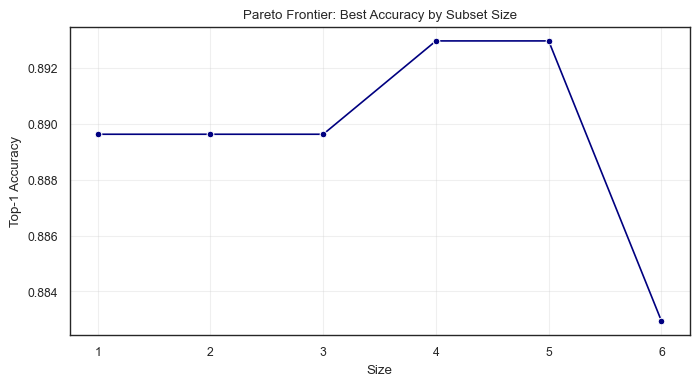

In [16]:
def analyze_feature_redundancy_robust(train_df, test_df):
    import itertools
    import numpy as np
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt
    from sklearn.linear_model import LogisticRegression
    from IPython.display import display, HTML

    # --- 1. Configuration ---
    features = ['Entropy', 'LogitGap', 'Heuristic', 'Mechanistic', 'Length', "Consistency"]
    # Auto-detect group column
    group_col = 'question_id_external' if 'question_id_external' in test_df.columns else 'question_text'

    # --- 2. Robust Group-wise Scaling ---
    def group_scale_robust(df, cols, group_col):
        """
        Standardizes data within groups (Z-score). 
        Handles NaNs by imputing the Z-score with 0 (the group mean).
        Handles constant groups (std=0) to avoid division by zero.
        """
        # A. Create a safe copy & coerce Infs to NaN
        local_df = df.copy()
        local_df[cols] = local_df[cols].replace([np.inf, -np.inf], np.nan)
        
        # B. Group Statistics (Pandas ignores NaNs by default)
        grouped = local_df.groupby(group_col)[cols]
        means = grouped.transform('mean')
        stds = grouped.transform('std')
        
        # C. Handle edge cases for Standard Deviation
        # If std is NaN (n=1) or 0 (all values same), replace with 1 to avoid div/0 errors
        stds = stds.fillna(1).replace(0, 1)
        
        # D. Calculate Z-Score
        # NaNs in input will propagate to NaNs here
        z = (local_df[cols] - means) / stds
        
        # E. Smart Imputation
        # Fill missing Z-scores with 0. 
        # In Z-space, 0 = "The Mean". This is the safest neutral assumption.
        return z.fillna(0)

    print("🛡️ Applying Robust Group-wise Scaling...")
    X_train = group_scale_robust(train_df, features, group_col)
    X_test = group_scale_robust(test_df, features, group_col)
    y_train = train_df['Correct']

    # Filter TEST set for multi-answer questions only
    mask_eval = test_df.groupby(group_col)[group_col].transform('count') > 1
    eval_df = test_df.loc[mask_eval, [group_col, 'Correct']].copy()
    
    if eval_df.empty: return print("⚠️ No multi-answer questions in Test DF.")

    print(f"🔍 Analyzing {2**len(features)-1} subsets on Train (n={len(train_df)}) vs Test (n={len(eval_df)})...")
    
    # --- 3. Brute-Force Search ---
    results = []
    subsets = itertools.chain.from_iterable(itertools.combinations(features, r) for r in range(1, len(features)+1))

    for subset in subsets:
        cols = list(subset)
        
        # Fit on TRAIN
        # solver='liblinear' is generally more robust to small datasets/outliers
        clf = LogisticRegression(class_weight='balanced', random_state=42, solver='liblinear')
        clf.fit(X_train[cols], y_train)
        
        # Predict on TEST
        eval_df['probs'] = clf.predict_proba(X_test.loc[eval_df.index, cols])[:, 1]
        
        # Score: Top-1 Accuracy
        best_idx = eval_df.groupby(group_col)['probs'].idxmax()
        acc = eval_df.loc[best_idx, 'Correct'].mean()
        
        results.append({
            'Size': len(cols), 
            'Features': ", ".join(cols),
            'Accuracy': acc
        })

    # --- 4. Outputs ---
    res_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
    
    # Marginal Impact Analysis
    impact_data = []
    for f in features:
        mask = res_df['Features'].str.contains(f)
        # Handle cases where a feature might be in ALL or NONE of the subsets (unlikely but safe)
        if mask.any() and (~mask).any():
            impact = res_df[mask]['Accuracy'].mean() - res_df[~mask]['Accuracy'].mean()
        else:
            impact = 0.0
        impact_data.append({'Feature': f, 'Marginal_Gain': impact})
    
    impact_df = pd.DataFrame(impact_data).sort_values('Marginal_Gain', ascending=False)

    # Visualization
    display(HTML("<h3>🚀 Feature Utility (Marginal Accuracy Gain)</h3>"))
    display(HTML(impact_df.style.bar(subset=['Marginal_Gain'], align='mid', color=['#e74c3c', '#27ae60'])
                 .format("{:.2%}", subset=['Marginal_Gain']).to_html()))
    
    display(HTML("<h3>🏆 Top 10 Feature Combinations</h3>"))
    display(HTML(res_df.head(10).style.background_gradient(subset=['Accuracy'], cmap='Greens')
                 .format("{:.2%}", subset=['Accuracy']).to_html()))

    plt.figure(figsize=(8, 4))
    sns.lineplot(data=res_df, x='Size', y='Accuracy', marker='o', color='navy', estimator=np.max, errorbar=None)
    plt.title("Pareto Frontier: Best Accuracy by Subset Size")
    plt.ylabel("Top-1 Accuracy")
    plt.grid(True, alpha=0.3)
    plt.show()

# Example Usage:
# analyze_feature_redundancy_robust(train_df, test_df)

# Usage:
analyze_feature_redundancy_robust(train_df, test_df)

🔎 Testing 15 metric combinations...
🏆 Top 10 Feature Combinations (Supervised Performance)


,Features,n_features,Supervised_AUROC,Unsupervised_AUROC,Feature_Set
5,Entropy + Length,2,0.816514,0.756214,"[Entropy, Length]"
6,Entropy + Mechanistic,2,0.813889,0.779517,"[Entropy, Mechanistic]"
8,Entropy + Heuristic,2,0.811879,0.734409,"[Entropy, Heuristic]"
0,Entropy,1,0.811399,0.776801,[Entropy]
7,Entropy + LogitGap,2,0.808893,0.751749,"[Entropy, LogitGap]"
12,Mechanistic + LogitGap,2,0.770506,0.740194,"[Mechanistic, LogitGap]"
13,Mechanistic + Heuristic,2,0.768911,0.731625,"[Mechanistic, Heuristic]"
2,Mechanistic,1,0.766690,0.751816,[Mechanistic]
9,Length + Mechanistic,2,0.766416,0.724611,"[Length, Mechanistic]"
10,Length + LogitGap,2,0.659852,0.649146,"[Length, LogitGap]"


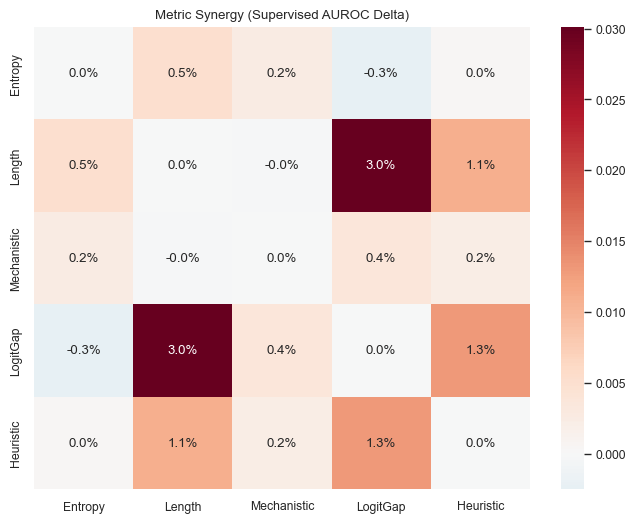

In [17]:
import itertools
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

def run_rigorous_metric_search(train_df, test_df, all_metrics):
    """
    Performs an exhaustive search of single and pairwise metrics 
    for both Supervised (Logistic) and Unsupervised (Clustering) settings.
    """
    
    # Store results here
    results = []
    
    # 1. SETUP: Iterate through different combination sizes (1 and 2)
    # You can increase '2' to 'len(all_metrics)' for full exhaustive search, 
    # but pairs are usually sufficient to find synergy.
    combos = []
    for r in range(1, 3): 
        combos.extend(list(itertools.combinations(all_metrics, r)))
        
    print(f"🔎 Testing {len(combos)} metric combinations...")
    
    for features in combos:
        feat_list = list(features)
        feat_name = " + ".join(feat_list)
        
        # --- A. SUPERVISED SEARCH (Logistic Regression) ---
        # 1. Train
        lr = LogisticRegression(class_weight='balanced', random_state=42)
        scaler = StandardScaler()
        
        X_train = scaler.fit_transform(train_df[feat_list].fillna(0))
        y_train = train_df['Correct']
        lr.fit(X_train, y_train)
        
        # 2. Test
        X_test = scaler.transform(test_df[feat_list].fillna(0))
        y_test = test_df['Correct']
        probs = lr.predict_proba(X_test)[:, 1]
        
        # 3. Score (AUROC)
        try:
            score_sup = roc_auc_score(y_test, probs)
        except:
            score_sup = 0.5
            
        # --- B. UNSUPERVISED SEARCH (Clustering) ---
        # 1. Cluster on Train
        # We use a fixed k=5 as a heuristic baseline
        km = KMeans(n_clusters=5, random_state=42, n_init=5)
        
        # Note: We use the same scaled data from above
        train_labels = km.fit_predict(X_train)
        
        # 2. Map Clusters to "Risk Scores" (Heuristic Probability)
        # For each cluster, calculating the win-rate on TRAIN
        temp_df = pd.DataFrame({'cluster': train_labels, 'correct': y_train})
        cluster_risk_map = temp_df.groupby('cluster')['correct'].mean().to_dict()
        
        # 3. Predict on Test
        test_labels = km.predict(X_test)
        # Assign the risk score based on the cluster the test point fell into
        cluster_probs = [cluster_risk_map.get(l, 0.5) for l in test_labels]
        
        # 4. Score (AUROC of the Cluster assignments)
        # This answers: "Did the clustering group correct items together?"
        try:
            score_unsup = roc_auc_score(y_test, cluster_probs)
        except:
            score_unsup = 0.5

        results.append({
            'Features': feat_name,
            'n_features': len(feat_list),
            'Supervised_AUROC': score_sup,
            'Unsupervised_AUROC': score_unsup,
            'Feature_Set': feat_list # Keep list for easier lookup later
        })

    return pd.DataFrame(results).sort_values('Supervised_AUROC', ascending=False)

# --- EXECUTION ---
metrics_pool = ["Entropy", "Length", "Mechanistic", "LogitGap", "Heuristic"]

# Run the search
df_results = run_rigorous_metric_search(train_df, test_df, metrics_pool)

# Display Top 10 Models
print("🏆 Top 10 Feature Combinations (Supervised Performance)")
display(df_results.head(10))

# --- C. SYNERGY HEATMAP ---
# We calculate: Score(A+B) - Max(Score(A), Score(B))
# If positive, A and B work better together than alone.
synergy_matrix = pd.DataFrame(index=metrics_pool, columns=metrics_pool, dtype=float)

# Pre-fill with single feature scores for quick lookup
single_scores = df_results[df_results['n_features'] == 1].set_index('Features')['Supervised_AUROC'].to_dict()

for idx, row in df_results[df_results['n_features'] == 2].iterrows():
    f1, f2 = row['Feature_Set']
    combined_score = row['Supervised_AUROC']
    
    # Baseline is the best of the two individual features
    baseline = max(single_scores.get(f1, 0.5), single_scores.get(f2, 0.5))
    
    # Synergy is the delta
    synergy = combined_score - baseline
    
    # Fill matrix (symmetric)
    synergy_matrix.loc[f1, f2] = synergy
    synergy_matrix.loc[f2, f1] = synergy

plt.figure(figsize=(8, 6))
sns.heatmap(synergy_matrix.fillna(0), annot=True, fmt=".1%", cmap="RdBu_r", center=0)
plt.title("Metric Synergy (Supervised AUROC Delta)")
plt.show()

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import numpy as np

def compare_metric_models(train_df, test_df, model_feature_map, k_clusters=5):
    """
    Races arbitrary lists of features against each other.
    
    Args:
        train_df (pd.DataFrame): Training data.
        test_df (pd.DataFrame): Test data.
        model_feature_map (dict): Dictionary where Key = Model Name, Value = List of features.
                                  e.g. {'Baseline': ['Entropy'], 'Advanced': ['Entropy', 'Length']}
        k_clusters (int): Number of clusters for the unsupervised baseline.
        
    Returns:
        pd.DataFrame: A leaderboard of all models sorted by Supervised AUROC.
    """
    
    results = []
    
    print(f"🏎️  Racing {len(model_feature_map)} model configurations...")
    
    for model_name, features in model_feature_map.items():
        # Validate features exist
        missing = [f for f in features if f not in train_df.columns]
        if missing:
            print(f"⚠️  Skipping '{model_name}': Missing columns {missing}")
            continue

        # --- PREPARATION ---
        scaler = StandardScaler()
        # fillna(0) is a safe default for standardizing metrics like these
        X_train = scaler.fit_transform(train_df[features].fillna(0))
        X_test = scaler.transform(test_df[features].fillna(0))
        y_train = train_df['Correct']
        y_test = test_df['Correct']
        
        # --- A. SUPERVISED TRACK (Logistic Regression) ---
        lr = LogisticRegression(class_weight='balanced', random_state=42)
        lr.fit(X_train, y_train)
        probs_sup = lr.predict_proba(X_test)[:, 1]
        
        try:
            score_sup = roc_auc_score(y_test, probs_sup)
        except:
            score_sup = 0.5
            
        # --- B. UNSUPERVISED TRACK (K-Means Clustering) ---
        # 1. Fit Clusters on Train
        km = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
        train_labels = km.fit_predict(X_train)
        
        # 2. Calculate "Risk" of each cluster (Win Rate on Train)
        # We map each cluster ID to its historical accuracy
        cluster_map = pd.DataFrame({'c': train_labels, 'y': y_train}).groupby('c')['y'].mean().to_dict()
        
        # 3. Predict on Test
        test_labels = km.predict(X_test)
        
        # 4. Assign Probabilities (The mean accuracy of the cluster you fell into)
        probs_unsup = np.array([cluster_map.get(l, 0.5) for l in test_labels])
        
        try:
            score_unsup = roc_auc_score(y_test, probs_unsup)
        except:
            score_unsup = 0.5

        # --- LOG RESULTS ---
        results.append({
            'Model Name': model_name,
            'Feature Count': len(features),
            'Features': ", ".join(features),
            'Supervised AUROC': score_sup,
            'Unsupervised AUROC': score_unsup,
            'Synergy Delta': score_sup - score_unsup # Positive = Supervision helps significantly
        })

    # Create Leaderboard
    df_res = pd.DataFrame(results).sort_values('Supervised AUROC', ascending=False).reset_index(drop=True)
    
    return df_res

# --- VISUALIZATION HELPER ---
def plot_model_comparison(df_results):
    """Visualizes the race results."""
    plt.figure(figsize=(10, 6))
    
    # Transform data for plotting (Melting)
    df_melt = df_results.melt(id_vars=['Model Name'], 
                              value_vars=['Supervised AUROC', 'Unsupervised AUROC'], 
                              var_name='Type', value_name='Score')
    
    sns.barplot(data=df_melt, x='Score', y='Model Name', hue='Type', palette='viridis')
    
    # Add baseline line (0.5 is random guessing)
    plt.axvline(0.5, color='red', linestyle='--', alpha=0.5)
    plt.title("Model Comparison: Supervised vs. Unsupervised Potential")
    plt.xlim(0.4, 1.0)
    plt.grid(axis='x', alpha=0.3)
    plt.show()

In [19]:
compare_metric_models(train_df, test_df, {"semantic only": ["Semantic"], "other": ["Entropy", "Length", "Mechanistic", "LogitGap"], "other consistent": ["Entropy", "Length", "Mechanistic", "LogitGap", "Consistency"]})

🏎️  Racing 3 model configurations...


,Model Name,Feature Count,Features,Supervised AUROC,Unsupervised AUROC,Synergy Delta
0,semantic only,1,Semantic,0.873677,0.873677,0.000000
1,other consistent,5,"Entropy, Length, Mechanistic, LogitGap, Consis...",0.825551,0.753260,0.072291
2,other,4,"Entropy, Length, Mechanistic, LogitGap",0.818438,0.737963,0.080474


In [20]:
compare_metric_models(train_df, test_df, {"semantic only": ["Semantic"], 
                                          "other": ["Entropy", "Length", "Mechanistic", "LogitGap"], 
                                          "other consistent": ["Entropy", "Length", "Mechanistic", "LogitGap", "Consistency"], 
                                          "length only": ["Length"], 
                                          "mechanistic and entropy": ["Mechanistic", "Entropy"],
                                          "entropy only": ["Entropy"], 
                                          "mechanistic only": ["Mechanistic"]
                                          })

🏎️  Racing 7 model configurations...


,Model Name,Feature Count,Features,Supervised AUROC,Unsupervised AUROC,Synergy Delta
0,semantic only,1,Semantic,0.873677,0.873677,0.000000
1,other consistent,5,"Entropy, Length, Mechanistic, LogitGap, Consis...",0.825551,0.753260,0.072291
2,other,4,"Entropy, Length, Mechanistic, LogitGap",0.818438,0.737963,0.080474
3,mechanistic and entropy,2,"Mechanistic, Entropy",0.813889,0.780161,0.033728
4,entropy only,1,Entropy,0.811399,0.776801,0.034599
5,mechanistic only,1,Mechanistic,0.766690,0.749537,0.017154
6,length only,1,Length,0.615580,0.626377,-0.010797


NameError: name 'HTML' is not defined

In [85]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import numpy as np
from IPython.display import display, HTML

def compare_metric_models(train_df, test_df, model_feature_map, k_clusters=5):
    """
    Races arbitrary lists of features against each other.
    Returns a styled HTML leaderboard.
    """
    results = []
    
    for model_name, features in model_feature_map.items():
        # Validate features exist
        valid_feats = [f for f in features if f in train_df.columns]
        if not valid_feats: continue

        # --- PREPARATION ---
        scaler = StandardScaler()
        X_train = scaler.fit_transform(train_df[valid_feats].fillna(0))
        X_test = scaler.transform(test_df[valid_feats].fillna(0))
        y_train, y_test = train_df['Correct'], test_df['Correct']
        
        # --- A. SUPERVISED (Logistic Regression) ---
        lr = LogisticRegression(class_weight='balanced', random_state=42)
        lr.fit(X_train, y_train)
        try: score_sup = roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1])
        except: score_sup = 0.5
            
        # --- B. UNSUPERVISED (K-Means) ---
        km = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
        train_labels = km.fit_predict(X_train)
        # Map cluster ID -> Win Rate
        cluster_map = pd.DataFrame({'c': train_labels, 'y': y_train}).groupby('c')['y'].mean().to_dict()
        test_labels = km.predict(X_test)
        probs_unsup = np.array([cluster_map.get(l, 0.5) for l in test_labels])
        
        try: score_unsup = roc_auc_score(y_test, probs_unsup)
        except: score_unsup = 0.5

        results.append({
            'Model Name': model_name,
            'Features': ", ".join(valid_feats),
            'Supervised AUROC': score_sup,
            'Unsupervised AUROC': score_unsup
        })

    # --- FORMATTING & DISPLAY ---
    df_res = pd.DataFrame(results).sort_values('Supervised AUROC', ascending=False).set_index('Model Name')
    
    # Render styled table
    styled = (df_res.style
        .format("{:.3f}", subset=['Supervised AUROC', 'Unsupervised AUROC'])
        .bar(subset=['Supervised AUROC', 'Unsupervised AUROC'], color='#5fba7d', vmin=0.5, vmax=1.0)
        .set_properties(**{'text-align': 'center', 'padding': '8px'})
        .set_table_styles([
            {'selector': 'th', 'props': [('background-color', '#f4f4f4'), ('color', '#333'), ('font-weight', 'bold')]},
            {'selector': 'caption', 'props': [('caption-side', 'top'), ('font-size', '1.2em'), ('font-weight', 'bold')]}
        ])
        .set_caption("🏆 Feature Configuration Leaderboard")
    )
    
    display(styled)
    return df_res

# Usage Example:
# models = {
#     'Baseline': ['Entropy'],
#     'Structure': ['Length'],
#     'Combined': ['Entropy', 'Length']
# }
# res = compare_metric_models(train_df, test_df, models)

In [102]:
compare_metric_models(train_df, test_df, {
                                            "Ensemble": ["Entropy", "Length", "Mechanistic", "LogitGap", "Semantic", "Consistency"],
                                            "Mini Ensemble": ["Semantic", "Consistency", "Entropy"],
                                            "Semantic+": ["Semantic", "Consistency"],
                                            "Semantic": ["Semantic"], 
                                          "One shot": ["Entropy", "Length", "Mechanistic", "LogitGap"],
                                          "Entropy+": ["Mechanistic", "Entropy"],
                                          "Entropy": ["Entropy"], 
                                          "Mechanistic": ["Mechanistic"],
                                          "Length": ["Length"], 
                                          "Consistency": ["Consistency"],
                                          "Min Logit Gap": ["LogitGap"]
                                           
                                          });

,Features,Supervised AUROC,Unsupervised AUROC
Model Name,,,
Mini Ensemble,"Semantic, Consistency, Entropy",0.903,0.856
Ensemble,"Entropy, Length, Mechanistic, LogitGap, Semantic, Consistency",0.902,0.827
Semantic+,"Semantic, Consistency",0.888,0.883
Semantic,Semantic,0.874,0.874
One shot,"Entropy, Length, Mechanistic, LogitGap",0.818,0.738
Entropy+,"Mechanistic, Entropy",0.814,0.780
Entropy,Entropy,0.811,0.777
Mechanistic,Mechanistic,0.767,0.750
Consistency,Consistency,0.749,0.721


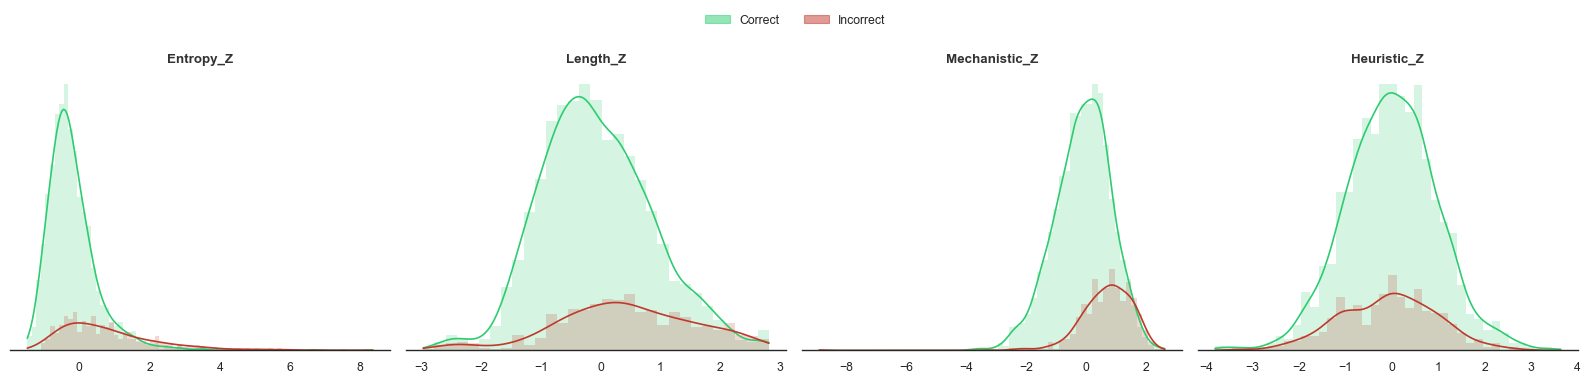

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_metric_histograms(df, metrics):
    """
    Plots a row of histograms for specific metrics, split by Correct/Incorrect.
    """
    valid_metrics = [m for m in metrics if m in df.columns]
    n = len(valid_metrics)
    
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 3.5))
    if n == 1: axes = [axes] # Handle single metric case

    for ax, m in zip(axes, valid_metrics):
        sns.histplot(
            data=df, x=m, hue='Correct',
            palette={0: "#c0392b", 1: "#2ecc71"}, # Red (Wrong) vs Green (Right)
            kde=True,               # Add density line
            element="step",         # Clean step-style bars
            common_norm=False,      # Normalize each group independently
            alpha=0.2, linewidth=0, # Transparency
            ax=ax
        )
        
        # Clean up aesthetics
        ax.set_title(m, fontweight='bold', color='#333')
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.get_yaxis().set_ticks([]) # Remove Y-axis numbers
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        
        # Remove individual legends to reduce clutter
        if ax.get_legend(): ax.get_legend().remove()

    # Add one shared legend at the top
    fig.legend(
        handles=[
            plt.Rectangle((0,0),1,1, color="#2ecc71", alpha=0.5),
            plt.Rectangle((0,0),1,1, color="#c0392b", alpha=0.5)
        ], 
        labels=['Correct', 'Incorrect'], 
        loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.1), frameon=False
    )

    plt.tight_layout()
    plt.show()

# Usage:
metrics = ['Entropy_Z', 'Length_Z', 'Mechanistic_Z', "Heuristic_Z"]
plot_metric_histograms(train_df, metrics)